# Dynamic World U-Net++ / DeepLabV3+ — CLEAN TRAIN NO RECOVERY

Bản này đã bỏ toàn bộ cell recovery/checkpoint-only evaluation. Quy trình đúng là chạy từ đầu đến cuối, train mới từng model và sau đó đánh giá test/report.
# Notebook 01 — U-Net++ và DeepLabV3+ cho phân loại sử dụng đất

Notebook này train semantic segmentation trên dataset Dynamic World/Sentinel-2 đã cắt patch.

Bản này đã được hoàn thiện để:
- chỉ train **U-Net++** và **DeepLabV3+**;
- tách quá trình train 2 mô hình thành **2 cell riêng biệt** để dễ debug;
- tự dùng **dual GPU Kaggle** bằng `torch.nn.DataParallel` nếu có từ 2 GPU trở lên;
- tự tính **class weights theo dataset hiện tại**;
- đánh giá trên tập test;
- lưu và hiển thị ảnh test/prediction để đưa vào báo cáo;
- vẽ learning curves, ROC/AUC, Precision-Recall, confusion matrix;
- xuất bảng so sánh cuối cùng.

## Bản hoàn thiện: Dual GPU + Dynamic class weights

Dataset hiện tại đã thay đổi phân bố lớp so với bản đầu, nên notebook này **không dùng class weights cố định cũ**.  
Weights được tính tự động từ tập train sau khi chia train/val/test.

Công thức mặc định:

```text
weight_c = sqrt(median_frequency / frequency_c)
```

Sau đó weight được giới hạn bởi `class_weight_min` và `class_weight_max`, rồi chuẩn hóa để trung bình gần 1.  
Cách này giúp lớp hiếm như `bare` được ưu tiên hơn nhưng không làm loss bị quá lớn.

## Bản sửa thứ tự cell cuối cùng

Notebook này đã được chỉnh lại để tránh lỗi thứ tự:
- `OUT_DIR` được tạo ngay sau `CONFIG`.
- `tqdm` được import trước khi dùng ROC/PR.
- Chỉ train `unetpp` và `deeplabv3plus`.
- Các training loop cũ đã bị vô hiệu hóa.
- Cell so sánh chạy sau khi có `results_df`.

In [237]:
import os, sys, time, math, json, random, warnings
from pathlib import Path
from collections import Counter, defaultdict

warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

try:
    import rasterio
except Exception:
    import subprocess
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "rasterio"])
    import rasterio

from PIL import Image

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, Subset

from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix

print("Python:", sys.version)
print("PyTorch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
from tqdm.auto import tqdm
from sklearn.metrics import roc_curve, auc, precision_recall_curve, average_precision_score

Python: 3.12.13 (main, Mar  4 2026, 09:23:07) [GCC 11.4.0]
PyTorch: 2.10.0+cu128
CUDA available: True
GPU: Tesla T4


In [238]:
# ==========================================================
# GPU / Multi-GPU setup
# ==========================================================
torch.backends.cudnn.benchmark = True

GPU_COUNT = torch.cuda.device_count()
print("CUDA available:", torch.cuda.is_available())
print("GPU count:", GPU_COUNT)
for i in range(GPU_COUNT):
    print(f"GPU {i}:", torch.cuda.get_device_name(i))

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Main device:", device)


def unwrap_model(model):
    """Lấy model gốc nếu đang bọc DataParallel."""
    return model.module if isinstance(model, nn.DataParallel) else model


def maybe_wrap_multi_gpu(model):
    """
    Dùng nn.DataParallel khi Kaggle bật 2 GPU.
    Cách này dễ dùng trong notebook hơn DDP.
    """
    if torch.cuda.is_available() and CONFIG.get("use_multi_gpu", True) and torch.cuda.device_count() > 1:
        gpu_ids = CONFIG.get("gpu_ids", None)
        if gpu_ids is None:
            gpu_ids = list(range(torch.cuda.device_count()))
        print("Using DataParallel on GPU ids:", gpu_ids)
        model = nn.DataParallel(model, device_ids=gpu_ids)
    else:
        print("Using single GPU/CPU.")
    return model.to(device)


def save_model_checkpoint(model, path, **extra):
    """
    Lưu checkpoint an toàn khi model có thể là DataParallel.
    """
    state = {
        "model_state_dict": unwrap_model(model).state_dict(),
        **extra,
    }
    torch.save(state, path)


def load_model_checkpoint(model, ckpt_path, map_location=None):
    """
    Load checkpoint vào model, hỗ trợ cả model thường và DataParallel.
    """
    ckpt = safe_torch_load(ckpt_path, map_location=map_location or device)
    unwrap_model(model).load_state_dict(ckpt["model_state_dict"])
    return ckpt

CUDA available: True
GPU count: 2
GPU 0: Tesla T4
GPU 1: Tesla T4
Main device: cuda


In [239]:
CONFIG = {
    "seed": 42,
    "output_dir": "/kaggle/working/dw_direct_compare" if Path("/kaggle/working").exists() else "./dw_direct_compare",
    "img_size": 128,
    "batch_size": 12,
    # Multi-GPU trên Kaggle: nếu bật 2 GPU, notebook tự dùng nn.DataParallel.
    "use_multi_gpu": False,
    "gpu_ids": None,  # None = dùng tất cả GPU khả dụng, ví dụ [0, 1]

    "epochs": 30,
    "lr": 1e-4,
    "weight_decay": 1e-4,
    "num_workers": 2,
    "prefetch_factor": 2,
    "persistent_workers": True,
    "base_channels": 32,
    "ignore_index": 255,
    "early_stopping_patience": 10,
    "use_5_classes": True,
    "models_to_run": ["unetpp", "deeplabv3plus"],

    # Dataset mới từ notebook 03 có thể có 8 band:
    # B2, B3, B4, B8, B11, NDVI, NDWI, NDBI.
    # Để tự dùng đúng số band, để auto_detect_input_channels=True.
    "auto_detect_input_channels": True,
    "max_channels": 8,
    "in_channels": 8,
    "use_confidence_filter": False,
            "confidence_threshold": 0.50,

        # Weighted loss để giảm lệch lớp:
        # 0 water, 1 vegetation, 2 agriculture, 3 built_up, 4 bare
        "use_class_weights": True,
    "auto_class_weights": True,
    "class_weights": None,
    "class_weight_strategy": "median_sqrt",
    "class_weight_min": 0.35,
    "class_weight_max": 3.50,
        "dice_weight": 0.70,
        "label_smoothing": 0.02,
        "grad_clip_norm": 1.0,

    # Lưu/in metric chi tiết theo từng epoch.
    "save_epoch_metrics_csv": True,
    "plot_roc_pr_curves": True,
    "roc_pr_max_batches": None,  # None = dùng toàn bộ test set

}
Path(CONFIG["output_dir"]).mkdir(parents=True, exist_ok=True)
CONFIG

{'seed': 42,
 'output_dir': '/kaggle/working/dw_direct_compare',
 'img_size': 128,
 'batch_size': 12,
 'use_multi_gpu': False,
 'gpu_ids': None,
 'epochs': 30,
 'lr': 0.0001,
 'weight_decay': 0.0001,
 'num_workers': 2,
 'prefetch_factor': 2,
 'persistent_workers': True,
 'base_channels': 32,
 'ignore_index': 255,
 'early_stopping_patience': 10,
 'use_5_classes': True,
 'models_to_run': ['unetpp', 'deeplabv3plus'],
 'auto_detect_input_channels': True,
 'max_channels': 8,
 'in_channels': 8,
 'use_confidence_filter': False,
 'confidence_threshold': 0.5,
 'use_class_weights': True,
 'auto_class_weights': True,
 'class_weights': None,
 'class_weight_strategy': 'median_sqrt',
 'class_weight_min': 0.35,
 'class_weight_max': 3.5,
 'dice_weight': 0.7,
 'label_smoothing': 0.02,
 'grad_clip_norm': 1.0,
 'save_epoch_metrics_csv': True,
 'plot_roc_pr_curves': True,
 'roc_pr_max_batches': None}

In [240]:
# ==========================================================
# Output directory - phải chạy trước dynamic weights/training
# ==========================================================
from pathlib import Path

OUT_DIR = Path(CONFIG.get("output_dir", "/kaggle/working/dynamicworld_training_outputs"))
OUT_DIR.mkdir(parents=True, exist_ok=True)

print("OUT_DIR:", OUT_DIR)

OUT_DIR: /kaggle/working/dw_direct_compare


## Dynamic class weights theo dataset hiện tại

Cell này chỉ **định nghĩa hàm** để đếm pixel từng lớp và tính class weights.  
Hàm sẽ được gọi sau khi `train_set/train_set/train_dataset` đã được tạo.

Notebook dùng `median_sqrt` thay vì inverse frequency trực tiếp để tránh weight quá lớn với lớp hiếm.

In [241]:
# ==========================================================
# Dynamic class weights from current train masks
# ==========================================================

def count_pixels_from_dataset(dataset, num_classes, ignore_index=255, desc="Count train masks"):
    counts = np.zeros(num_classes, dtype=np.int64)
    ignore_count = 0

    for idx in tqdm(range(len(dataset)), desc=desc):
        _, mask = dataset[idx]
        mask_np = mask.numpy() if hasattr(mask, "numpy") else np.asarray(mask)

        ignore_count += int((mask_np == ignore_index).sum())

        valid = mask_np != ignore_index
        if valid.sum() == 0:
            continue

        vals, cnts = np.unique(mask_np[valid], return_counts=True)
        for v, c in zip(vals, cnts):
            v = int(v)
            if 0 <= v < num_classes:
                counts[v] += int(c)

    return counts, ignore_count


def compute_dynamic_class_weights_from_counts(counts, strategy="median_sqrt", w_min=0.35, w_max=3.50, eps=1e-6):
    counts = np.asarray(counts, dtype=np.float64)
    total = counts.sum()

    if total <= 0:
        return np.ones_like(counts, dtype=np.float32)

    freq = counts / max(total, eps)
    nonzero = freq[freq > 0]

    if len(nonzero) == 0:
        return np.ones_like(counts, dtype=np.float32)

    median_freq = np.median(nonzero)

    if strategy == "median":
        weights = median_freq / np.maximum(freq, eps)
    elif strategy == "median_sqrt":
        weights = np.sqrt(median_freq / np.maximum(freq, eps))
    elif strategy == "inverse_sqrt":
        weights = 1.0 / np.sqrt(np.maximum(freq, eps))
        weights = weights / np.mean(weights[freq > 0])
    else:
        raise ValueError(f"Unknown class weight strategy: {strategy}")

    # Nếu lớp không xuất hiện trong train set, không cho weight cực lớn.
    weights[freq <= 0] = 1.0

    # Chặn biên để loss ổn định.
    weights = np.clip(weights, w_min, w_max)

    # Chuẩn hóa trung bình về 1.
    weights = weights / np.mean(weights)

    return weights.astype(np.float32)


def update_class_weights_from_train_dataset(train_dataset, num_classes):
    if not CONFIG.get("use_class_weights", True):
        CONFIG["class_weights"] = None
        return None

    if not CONFIG.get("auto_class_weights", True) and CONFIG.get("class_weights") is not None:
        print("Using manual class weights from CONFIG:")
        for name, w in zip(class_names, CONFIG["class_weights"]):
            print(f"  {name:<12}: {w:.3f}")
        return np.asarray(CONFIG["class_weights"], dtype=np.float32)

    counts, ignore_count = count_pixels_from_dataset(
        train_dataset,
        num_classes=num_classes,
        ignore_index=CONFIG["ignore_index"],
        desc="Count train masks for dynamic weights",
    )

    valid_total = counts.sum()
    ratios = counts / max(valid_total, 1)

    dist_df = pd.DataFrame({
        "class_id": list(range(num_classes)),
        "class_name": class_names,
        "pixel_count": counts,
        "ratio_no_ignore": ratios,
    })

    print("Train class distribution used for dynamic class weights:")
    display(dist_df)

    weights = compute_dynamic_class_weights_from_counts(
        counts,
        strategy=CONFIG.get("class_weight_strategy", "median_sqrt"),
        w_min=CONFIG.get("class_weight_min", 0.35),
        w_max=CONFIG.get("class_weight_max", 3.50),
    )

    CONFIG["class_weights"] = [float(x) for x in weights]

    print("Dynamic class weights:")
    for name, w in zip(class_names, weights):
        print(f"  {name:<12}: {w:.3f}")

    print("Ignored pixels in train set:", ignore_count)

    weight_df = dist_df.copy()
    weight_df["class_weight"] = weights
    weight_df.to_csv(OUT_DIR / "train_class_distribution_and_weights.csv", index=False)

    return weights

In [242]:
IMG_EXTS = {".tif", ".tiff", ".png", ".jpg", ".jpeg", ".bmp"}

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.benchmark = True

set_seed(CONFIG["seed"])
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

def list_image_files(root):
    root = Path(root)
    if not root.exists():
        return []
    files = []
    for ext in IMG_EXTS:
        files.extend(root.rglob(f"*{ext}"))
        files.extend(root.rglob(f"*{ext.upper()}"))
    return sorted(files)

def normalize_image_array(arr):
    # Chuẩn hóa ảnh về float32 trong khoảng 0..1.
    # OpenEarthMap RGB thường 0..255, Sentinel-2 SR thường 0..10000 hoặc 0..1.
    arr = arr.astype(np.float32)
    arr = np.nan_to_num(arr, nan=0.0, posinf=0.0, neginf=0.0)
    if arr.size == 0:
        return arr

    max_val = float(np.max(arr))
    if max_val <= 1.5:
        return np.clip(arr, 0.0, 1.0)
    if max_val <= 255.0:
        return np.clip(arr / 255.0, 0.0, 1.0)
    if max_val <= 10000.0:
        return np.clip(arr / 10000.0, 0.0, 1.0)
    if max_val <= 65535.0:
        return np.clip(arr / 65535.0, 0.0, 1.0)

    p2, p98 = np.percentile(arr, [2, 98])
    if p98 > p2:
        arr = (arr - p2) / (p98 - p2)
    return np.clip(arr, 0.0, 1.0)

def stretch_for_display(img_chw, percentile=(2, 98)):
    # Convert ảnh C,H,W hoặc H,W,C thành H,W,3 để hiển thị.
    img = np.asarray(img_chw)
    if img.ndim == 3 and img.shape[0] <= 16:
        if img.shape[0] >= 4:
            img = np.stack([img[2], img[1], img[0]], axis=-1)  # B4,B3,B2
        else:
            img = img[:3].transpose(1, 2, 0)
    elif img.ndim == 3:
        img = img[:, :, :3]
    else:
        raise ValueError(f"Unsupported image shape: {img.shape}")

    img = normalize_image_array(img)
    lo, hi = np.percentile(img, percentile)
    if hi > lo:
        img = (img - lo) / (hi - lo)
    return np.clip(img, 0, 1)

def read_image_any(path, max_channels=CONFIG["in_channels"]):
    path = Path(path)
    if path.suffix.lower() in [".tif", ".tiff"]:
        with rasterio.open(path) as src:
            arr = src.read()
    else:
        arr = np.array(Image.open(path).convert("RGB")).transpose(2, 0, 1)

    arr = normalize_image_array(arr)

    if arr.shape[0] >= max_channels:
        arr = arr[:max_channels]
    else:
        pad = np.zeros((max_channels - arr.shape[0], arr.shape[1], arr.shape[2]), dtype=np.float32)
        arr = np.concatenate([arr, pad], axis=0)
    return arr.astype(np.float32)

def read_mask_any(path):
    path = Path(path)
    if path.suffix.lower() in [".tif", ".tiff"]:
        with rasterio.open(path) as src:
            arr = src.read()
        if arr.ndim == 3:
            if arr.shape[0] == 1:
                mask = arr[0]
            elif arr.shape[0] >= 3:
                rgb = np.stack([arr[0], arr[1], arr[2]], axis=-1).astype(np.uint8)
                colors = np.unique(rgb.reshape(-1, 3), axis=0)
                mask = np.zeros(rgb.shape[:2], dtype=np.int64)
                for i, c in enumerate(colors):
                    mask[np.all(rgb == c, axis=-1)] = i
            else:
                mask = arr[0]
        else:
            mask = arr
    else:
        arr = np.array(Image.open(path))
        if arr.ndim == 2:
            mask = arr
        else:
            rgb = arr[:, :, :3].astype(np.uint8)
            colors = np.unique(rgb.reshape(-1, 3), axis=0)
            mask = np.zeros(rgb.shape[:2], dtype=np.int64)
            for i, c in enumerate(colors):
                mask[np.all(rgb == c, axis=-1)] = i
    return mask.astype(np.int64)

def match_pairs(image_dir, mask_dir):
    images = list_image_files(image_dir)
    masks = list_image_files(mask_dir)
    mask_by_stem = {p.stem: p for p in masks}
    pairs = []
    for ip in images:
        if ip.stem in mask_by_stem:
            pairs.append((ip, mask_by_stem[ip.stem]))
    if len(pairs) == 0:
        n = min(len(images), len(masks))
        pairs = list(zip(images[:n], masks[:n]))
    return pairs

def safe_torch_load(path, map_location="cpu"):
    try:
        return torch.load(path, map_location=map_location, weights_only=False)
    except TypeError:
        return torch.load(path, map_location=map_location)

In [243]:
DW9_CLASS_NAMES = [
    "water", "trees", "grass", "flooded_vegetation", "crops",
    "shrub_and_scrub", "built", "bare", "snow_and_ice"
]
DW5_CLASS_NAMES = ["water", "vegetation", "agriculture", "built_up", "bare"]

DW_REMAP_5 = {
    0: 0, 1: 1, 2: 1, 3: 1, 4: 2, 5: 1, 6: 3, 7: 4, 8: 255
}

PALETTE_5 = np.array([
    [65, 155, 223], [57, 125, 73], [228, 150, 53], [196, 40, 27], [165, 155, 143]
], dtype=np.uint8)

PALETTE_9 = np.array([
    [65, 155, 223], [57, 125, 73], [136, 176, 83],
    [122, 135, 198], [228, 150, 53], [223, 195, 90],
    [196, 40, 27], [165, 155, 143], [179, 159, 225],
], dtype=np.uint8)

def remap_dynamic_mask(mask, use_5_classes=True, ignore_index=255):
    mask = mask.astype(np.int64)
    if not use_5_classes:
        out = np.where((mask >= 0) & (mask <= 8), mask, ignore_index)
        return out.astype(np.int64)

    out = np.full_like(mask, fill_value=ignore_index, dtype=np.int64)
    for src, dst in DW_REMAP_5.items():
        out[mask == src] = dst
    return out

def colorize_mask(mask, palette):
    mask = np.asarray(mask)
    out = np.zeros((mask.shape[0], mask.shape[1], 3), dtype=np.uint8)
    valid = (mask >= 0) & (mask < len(palette))
    out[valid] = palette[mask[valid]]
    out[mask == 255] = [0, 0, 0]
    return out

## 1. Tự dò dataset Dynamic World

Nếu notebook dò sai, sửa thủ công:

```python
DW_ROOT = Path("/kaggle/input/land-cover-dynamic")
IMAGE_DIR = DW_ROOT / "images"
MASK_DIR = DW_ROOT / "masks"
CONF_DIR = DW_ROOT / "confidence"
```

In [244]:
def find_dynamic_dataset_root(search_root="/kaggle/input"):
    root = Path(search_root)
    candidates = []
    if not root.exists():
        return candidates
    for p in root.rglob("*"):
        if not p.is_dir():
            continue
        if (p / "images").exists() and (p / "masks").exists():
            n_img = len(list_image_files(p / "images"))
            n_mask = len(list_image_files(p / "masks"))
            if n_img > 0 and n_mask > 0:
                candidates.append((p, n_img, n_mask, min(n_img, n_mask)))
    return sorted(candidates, key=lambda x: x[-1], reverse=True)

dw_candidates = find_dynamic_dataset_root("/kaggle/input")
pd.DataFrame(dw_candidates, columns=["root", "num_images", "num_masks", "score"]).head(20)

,root,num_images,num_masks,score
0,/kaggle/input/datasets/vnphnphm/land-cover-dyn...,2000,2000,2000


In [245]:
if len(dw_candidates) > 0:
    DW_ROOT = Path(dw_candidates[0][0])
else:
    DW_ROOT = Path("/kaggle/input/land-cover-dynamic")

IMAGE_DIR = DW_ROOT / "images"
MASK_DIR = DW_ROOT / "masks"
CONF_DIR = DW_ROOT / "confidence"

print("DW_ROOT:", DW_ROOT)
print("images:", len(list_image_files(IMAGE_DIR)))
print("masks :", len(list_image_files(MASK_DIR)))
print("confidence:", len(list_image_files(CONF_DIR)) if CONF_DIR.exists() else 0)

DW_ROOT: /kaggle/input/datasets/vnphnphm/land-cover-dynamic
images: 2000
masks : 2000
confidence: 2000


## 1.1. Tự phát hiện số band ảnh đầu vào

In [246]:
def detect_image_band_count(image_dir):
    files = list_image_files(image_dir)
    if len(files) == 0:
        return 4

    sample = files[0]
    if sample.suffix.lower() in [".tif", ".tiff"]:
        with rasterio.open(sample) as src:
            return int(src.count)
    return 3

detected_bands = detect_image_band_count(IMAGE_DIR)

if CONFIG.get("auto_detect_input_channels", True):
    CONFIG["in_channels"] = min(detected_bands, CONFIG.get("max_channels", detected_bands))
else:
    CONFIG["in_channels"] = CONFIG.get("in_channels", 4)

CONFIG["max_channels"] = CONFIG["in_channels"]

print("Detected image bands:", detected_bands)
print("Using input channels:", CONFIG["in_channels"])

# Ghi chú band nếu dataset được tạo từ notebook 03 mới:
if CONFIG["in_channels"] == 8:
    print("Band order expected: B2, B3, B4, B8, B11, NDVI, NDWI, NDBI")
elif CONFIG["in_channels"] == 4:
    print("Band order expected: B2, B3, B4, B8")

Detected image bands: 8
Using input channels: 8
Band order expected: B2, B3, B4, B8, B11, NDVI, NDWI, NDBI


## 2. Dataset class và tiền xử lý

In [247]:
class DynamicWorldDataset(Dataset):
    def __init__(self, image_dir, mask_dir, conf_dir=None, img_size=128, augment=False, max_channels=CONFIG["in_channels"]):
        self.pairs = match_pairs(image_dir, mask_dir)
        self.conf_dir = Path(conf_dir) if conf_dir is not None and Path(conf_dir).exists() else None
        self.img_size = img_size
        self.augment = augment
        self.max_channels = max_channels

    def __len__(self):
        return len(self.pairs)

    def _read_confidence(self, image_path):
        if self.conf_dir is None:
            return None
        candidates = list(self.conf_dir.glob(image_path.stem + ".*"))
        if not candidates:
            return None
        with rasterio.open(candidates[0]) as src:
            return src.read(1).astype(np.float32)

    def _resize(self, image, mask, conf=None):
        image_t = torch.from_numpy(image).float().unsqueeze(0)
        mask_t = torch.from_numpy(mask).long().unsqueeze(0).unsqueeze(0).float()
        image_t = F.interpolate(image_t, size=(self.img_size, self.img_size), mode="bilinear", align_corners=False)
        mask_t = F.interpolate(mask_t, size=(self.img_size, self.img_size), mode="nearest")
        image = image_t.squeeze(0)
        mask = mask_t.squeeze(0).squeeze(0).long()
        if conf is not None:
            conf_t = torch.from_numpy(conf).float().unsqueeze(0).unsqueeze(0)
            conf_t = F.interpolate(conf_t, size=(self.img_size, self.img_size), mode="bilinear", align_corners=False)
            conf = conf_t.squeeze(0).squeeze(0)
        return image, mask, conf

    def _augment(self, image, mask):
        if random.random() < 0.5:
            image = torch.flip(image, dims=[2]); mask = torch.flip(mask, dims=[1])
        if random.random() < 0.5:
            image = torch.flip(image, dims=[1]); mask = torch.flip(mask, dims=[0])
        k = random.randint(0, 3)
        if k > 0:
            image = torch.rot90(image, k, dims=[1, 2]); mask = torch.rot90(mask, k, dims=[0, 1])
        return image, mask

    def __getitem__(self, idx):
        img_path, mask_path = self.pairs[idx]
        image = read_image_any(img_path, max_channels=self.max_channels)
        mask = read_mask_any(mask_path)

        valid_vals = mask[mask != CONFIG["ignore_index"]]
        if CONFIG["use_5_classes"] and valid_vals.size > 0 and valid_vals.max() <= 4:
            mask = mask.astype(np.int64)
        else:
            mask = remap_dynamic_mask(mask, CONFIG["use_5_classes"], CONFIG["ignore_index"])

        conf = self._read_confidence(img_path)
        image, mask, conf = self._resize(image, mask, conf)

        if CONFIG["use_confidence_filter"] and conf is not None:
            mask = mask.clone()
            mask[conf < CONFIG["confidence_threshold"]] = CONFIG["ignore_index"]

        if self.augment:
            image, mask = self._augment(image, mask)

        return image.float(), mask.long()

num_classes = 5 if CONFIG["use_5_classes"] else 9
class_names = DW5_CLASS_NAMES if CONFIG["use_5_classes"] else DW9_CLASS_NAMES
palette = PALETTE_5 if CONFIG["use_5_classes"] else PALETTE_9

## 3. Visual và phân tích dữ liệu

Total samples: 2000


,class_id,class_name,pixel_count,ratio
0,0,water,3307296,0.100931
1,1,vegetation,6211497,0.189560
2,2,agriculture,4983319,0.152079
3,3,built_up,8348409,0.254773
4,4,bare,525577,0.016039
5,255,ignore,9391902,0.286618


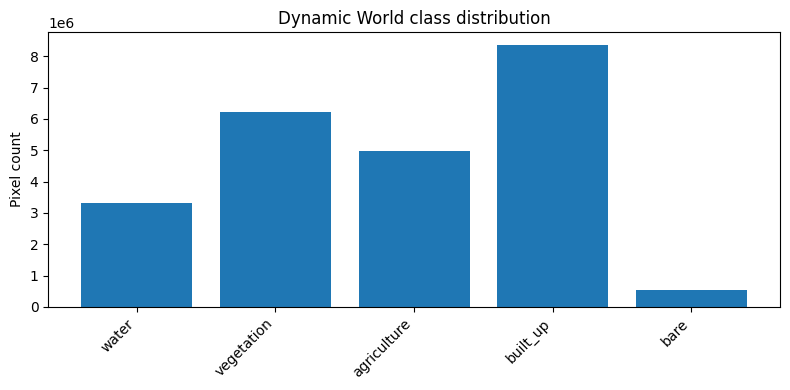

In [248]:
full_dataset_aug = DynamicWorldDataset(IMAGE_DIR, MASK_DIR, CONF_DIR, CONFIG["img_size"], augment=True, max_channels=CONFIG["in_channels"])
full_dataset_eval = DynamicWorldDataset(IMAGE_DIR, MASK_DIR, CONF_DIR, CONFIG["img_size"], augment=False, max_channels=CONFIG["in_channels"])

print("Total samples:", len(full_dataset_eval))

counts = Counter()
for i in range(len(full_dataset_eval)):
    _, mask = full_dataset_eval[i]
    vals, cnts = torch.unique(mask, return_counts=True)
    for v, c in zip(vals.tolist(), cnts.tolist()):
        counts[int(v)] += int(c)

dist_rows = []
for k, v in sorted(counts.items()):
    name = "ignore" if k == 255 else (class_names[k] if 0 <= k < len(class_names) else "unknown")
    dist_rows.append({"class_id": k, "class_name": name, "pixel_count": v})
dist_df = pd.DataFrame(dist_rows)
dist_df["ratio"] = dist_df["pixel_count"] / dist_df["pixel_count"].sum()
dist_df.to_csv(Path(CONFIG["output_dir"]) / "data_class_distribution.csv", index=False)
display(dist_df)

plot_df = dist_df[dist_df["class_id"] != 255]
plt.figure(figsize=(8, 4))
plt.bar(plot_df["class_name"], plot_df["pixel_count"])
plt.xticks(rotation=45, ha="right")
plt.title("Dynamic World class distribution")
plt.ylabel("Pixel count")
plt.tight_layout()
plt.savefig(Path(CONFIG["output_dir"]) / "data_class_distribution.png", dpi=160)
plt.show()

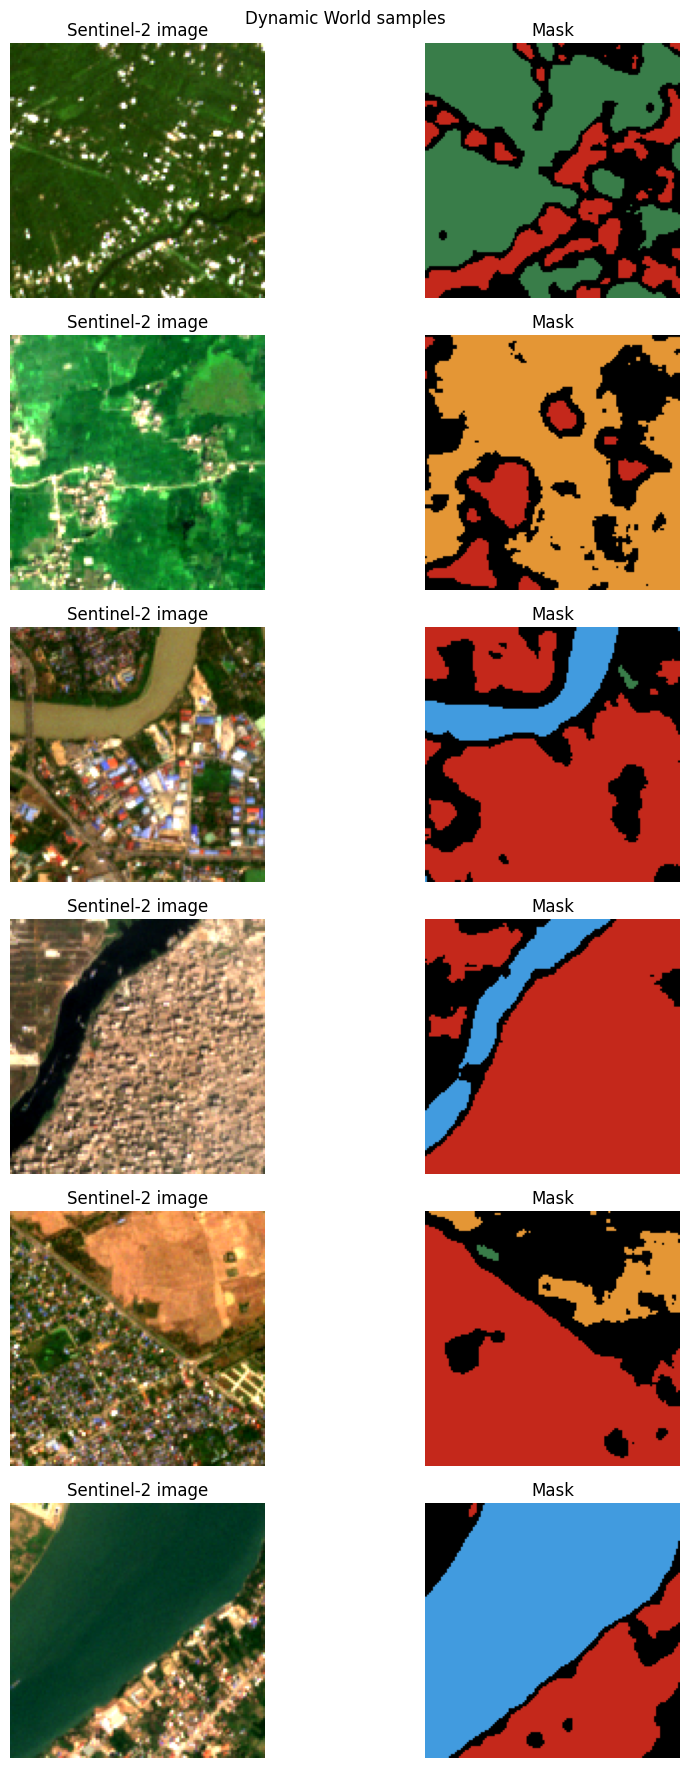

In [249]:
def show_dataset_samples(dataset, n=6, title="Dynamic World samples"):
    n = min(n, len(dataset))
    idxs = np.random.choice(len(dataset), size=n, replace=False)
    plt.figure(figsize=(10, n * 3))
    for row, idx in enumerate(idxs):
        img, mask = dataset[idx]
        plt.subplot(n, 2, row * 2 + 1)
        plt.imshow(stretch_for_display(img.numpy()))
        plt.title("Sentinel-2 image")
        plt.axis("off")
        plt.subplot(n, 2, row * 2 + 2)
        plt.imshow(colorize_mask(mask.numpy(), palette))
        plt.title("Mask")
        plt.axis("off")
    plt.suptitle(title)
    plt.tight_layout()
    plt.savefig(Path(CONFIG["output_dir"]) / "data_samples.png", dpi=160)
    plt.show()

show_dataset_samples(full_dataset_eval, n=6)

### Lưu ý về lệch lớp

Nếu biểu đồ phân bố lớp vẫn quá nhiều `water` hoặc `built_up`, cần tạo lại dataset bằng notebook cắt patch bản `BALANCED_WATER_REDUCED`.  
Notebook train này đã thêm weighted loss, nhưng dữ liệu đầu vào vẫn là yếu tố quan trọng nhất.

## 4. Chia train/val/test

In [250]:
indices = np.arange(len(full_dataset_eval))
train_idx, temp_idx = train_test_split(indices, train_size=0.70, random_state=CONFIG["seed"], shuffle=True)
val_idx, test_idx = train_test_split(temp_idx, train_size=0.50, random_state=CONFIG["seed"], shuffle=True)

train_set = Subset(full_dataset_aug, train_idx)
val_set = Subset(full_dataset_eval, val_idx)
test_set = Subset(full_dataset_eval, test_idx)

# Alias để các cell phía sau dùng tên thống nhất.
train_dataset = train_set
val_dataset = val_set
test_dataset = test_set

train_loader = DataLoader(
    train_set,
    batch_size=CONFIG["batch_size"],
    shuffle=True,
    num_workers=CONFIG["num_workers"],
    pin_memory=True,
    persistent_workers=CONFIG.get("persistent_workers", False) if CONFIG["num_workers"] > 0 else False,
    prefetch_factor=CONFIG.get("prefetch_factor", 2) if CONFIG["num_workers"] > 0 else None,
)
val_loader = DataLoader(
    val_set,
    batch_size=CONFIG["batch_size"],
    shuffle=False,
    num_workers=CONFIG["num_workers"],
    pin_memory=True,
    persistent_workers=CONFIG.get("persistent_workers", False) if CONFIG["num_workers"] > 0 else False,
    prefetch_factor=CONFIG.get("prefetch_factor", 2) if CONFIG["num_workers"] > 0 else None,
)
test_loader = DataLoader(
    test_set,
    batch_size=CONFIG["batch_size"],
    shuffle=False,
    num_workers=CONFIG["num_workers"],
    pin_memory=True,
    persistent_workers=CONFIG.get("persistent_workers", False) if CONFIG["num_workers"] > 0 else False,
    prefetch_factor=CONFIG.get("prefetch_factor", 2) if CONFIG["num_workers"] > 0 else None,
)

split_df = pd.DataFrame({"split": ["train", "val", "test"], "num_samples": [len(train_set), len(val_set), len(test_set)]})
split_df.to_csv(Path(CONFIG["output_dir"]) / "split_info.csv", index=False)
split_df

,split,num_samples
0,train,1400
1,val,300
2,test,300


In [251]:
# ==========================================================
# Update class weights after train/val/test split
# ==========================================================
# Phải chạy sau khi tạo train_set/train_dataset, trước khi build loss/train model.
# Nếu dataset thay đổi, weight sẽ tự tính lại theo phân bố mới.

if "train_dataset" not in globals():
    if "train_set" in globals():
        train_dataset = train_set
    else:
        raise NameError("Chưa có train_set/train_dataset. Hãy chạy cell chia train/val/test trước.")

dynamic_weights = update_class_weights_from_train_dataset(
    train_dataset,
    num_classes=num_classes,
)

print("CONFIG['class_weights'] =", CONFIG.get("class_weights"))

Count train masks for dynamic weights:   0%|          | 0/1400 [00:00<?, ?it/s]

Train class distribution used for dynamic class weights:


,class_id,class_name,pixel_count,ratio_no_ignore
0,0,water,2362458,0.144286
1,1,vegetation,4227186,0.258173
2,2,agriculture,3385890,0.206792
3,3,built_up,5972151,0.364746
4,4,bare,425754,0.026003


Dynamic class weights:
  water       : 0.898
  vegetation  : 0.671
  agriculture : 0.750
  built_up    : 0.565
  bare        : 2.116
Ignored pixels in train set: 6564161
CONFIG['class_weights'] = [0.8980787396430969, 0.6713836789131165, 0.7501705884933472, 0.5648472905158997, 2.1155197620391846]


## 5. Mô hình và hàm train/evaluate

In [252]:
# ==========================================================
# Models: U-Net++ và DeepLabV3+
# ==========================================================

class ConvBlock(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
        )

    def forward(self, x):
        return self.block(x)


class UNetPlusPlusSmall(nn.Module):
    """
    U-Net++ bản nhỏ với nested skip connections.
    """
    def __init__(self, in_channels, num_classes, base=32):
        super().__init__()
        nb = [base, base * 2, base * 4, base * 8, base * 16]
        self.pool = nn.MaxPool2d(2)

        self.conv0_0 = ConvBlock(in_channels, nb[0])
        self.conv1_0 = ConvBlock(nb[0], nb[1])
        self.conv2_0 = ConvBlock(nb[1], nb[2])
        self.conv3_0 = ConvBlock(nb[2], nb[3])
        self.conv4_0 = ConvBlock(nb[3], nb[4])

        self.conv0_1 = ConvBlock(nb[0] + nb[1], nb[0])
        self.conv1_1 = ConvBlock(nb[1] + nb[2], nb[1])
        self.conv2_1 = ConvBlock(nb[2] + nb[3], nb[2])
        self.conv3_1 = ConvBlock(nb[3] + nb[4], nb[3])

        self.conv0_2 = ConvBlock(nb[0] * 2 + nb[1], nb[0])
        self.conv1_2 = ConvBlock(nb[1] * 2 + nb[2], nb[1])
        self.conv2_2 = ConvBlock(nb[2] * 2 + nb[3], nb[2])

        self.conv0_3 = ConvBlock(nb[0] * 3 + nb[1], nb[0])
        self.conv1_3 = ConvBlock(nb[1] * 3 + nb[2], nb[1])

        self.conv0_4 = ConvBlock(nb[0] * 4 + nb[1], nb[0])
        self.final = nn.Conv2d(nb[0], num_classes, kernel_size=1)

    def up(self, x, size):
        return F.interpolate(x, size=size, mode="bilinear", align_corners=False)

    def forward(self, x):
        x0_0 = self.conv0_0(x)
        x1_0 = self.conv1_0(self.pool(x0_0))
        x2_0 = self.conv2_0(self.pool(x1_0))
        x3_0 = self.conv3_0(self.pool(x2_0))
        x4_0 = self.conv4_0(self.pool(x3_0))

        x0_1 = self.conv0_1(torch.cat([x0_0, self.up(x1_0, x0_0.shape[2:])], dim=1))
        x1_1 = self.conv1_1(torch.cat([x1_0, self.up(x2_0, x1_0.shape[2:])], dim=1))
        x2_1 = self.conv2_1(torch.cat([x2_0, self.up(x3_0, x2_0.shape[2:])], dim=1))
        x3_1 = self.conv3_1(torch.cat([x3_0, self.up(x4_0, x3_0.shape[2:])], dim=1))

        x0_2 = self.conv0_2(torch.cat([x0_0, x0_1, self.up(x1_1, x0_0.shape[2:])], dim=1))
        x1_2 = self.conv1_2(torch.cat([x1_0, x1_1, self.up(x2_1, x1_0.shape[2:])], dim=1))
        x2_2 = self.conv2_2(torch.cat([x2_0, x2_1, self.up(x3_1, x2_0.shape[2:])], dim=1))

        x0_3 = self.conv0_3(torch.cat([x0_0, x0_1, x0_2, self.up(x1_2, x0_0.shape[2:])], dim=1))
        x1_3 = self.conv1_3(torch.cat([x1_0, x1_1, x1_2, self.up(x2_2, x1_0.shape[2:])], dim=1))

        x0_4 = self.conv0_4(torch.cat([x0_0, x0_1, x0_2, x0_3, self.up(x1_3, x0_0.shape[2:])], dim=1))

        return self.final(x0_4)


class ASPP(nn.Module):
    def __init__(self, in_ch, out_ch, rates=(1, 3, 6, 9)):
        super().__init__()
        branches = []
        for r in rates:
            if r == 1:
                branches.append(nn.Sequential(
                    nn.Conv2d(in_ch, out_ch, kernel_size=1, bias=False),
                    nn.BatchNorm2d(out_ch),
                    nn.ReLU(inplace=True),
                ))
            else:
                branches.append(nn.Sequential(
                    nn.Conv2d(in_ch, out_ch, kernel_size=3, padding=r, dilation=r, bias=False),
                    nn.BatchNorm2d(out_ch),
                    nn.ReLU(inplace=True),
                ))

        self.branches = nn.ModuleList(branches)

        self.global_pool = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),
            nn.Conv2d(in_ch, out_ch, kernel_size=1, bias=False),
            nn.ReLU(inplace=True),
        )

        self.project = nn.Sequential(
            nn.Conv2d(out_ch * (len(rates) + 1), out_ch, kernel_size=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
            nn.Dropout(0.1),
        )

    def forward(self, x):
        size = x.shape[2:]
        feats = [branch(x) for branch in self.branches]
        gp = self.global_pool(x)
        gp = F.interpolate(gp, size=size, mode="bilinear", align_corners=False)
        feats.append(gp)
        return self.project(torch.cat(feats, dim=1))


class DeepLabV3PlusSmall(nn.Module):
    """
    DeepLabV3+ bản nhẹ: encoder CNN + ASPP + decoder low-level feature.
    """
    def __init__(self, in_channels, num_classes, base=32):
        super().__init__()
        self.stem = ConvBlock(in_channels, base)
        self.enc1 = ConvBlock(base, base * 2)
        self.enc2 = ConvBlock(base * 2, base * 4)
        self.enc3 = ConvBlock(base * 4, base * 8)
        self.pool = nn.MaxPool2d(2)

        self.aspp = ASPP(base * 8, base * 4)

        self.low_proj = nn.Sequential(
            nn.Conv2d(base, base, kernel_size=1, bias=False),
            nn.BatchNorm2d(base),
            nn.ReLU(inplace=True),
        )

        self.decoder = nn.Sequential(
            ConvBlock(base * 4 + base, base * 2),
            nn.Conv2d(base * 2, num_classes, kernel_size=1),
        )

    def forward(self, x):
        input_size = x.shape[2:]

        low = self.stem(x)
        x = self.enc1(self.pool(low))
        x = self.enc2(self.pool(x))
        x = self.enc3(self.pool(x))

        x = self.aspp(x)
        x = F.interpolate(x, size=low.shape[2:], mode="bilinear", align_corners=False)

        low = self.low_proj(low)
        x = self.decoder(torch.cat([x, low], dim=1))
        x = F.interpolate(x, size=input_size, mode="bilinear", align_corners=False)
        return x


def build_model(name, in_channels, num_classes):
    name = name.lower()
    base = CONFIG["base_channels"]

    if name in ["unetpp", "unet++", "unetplusplus"]:
        return UNetPlusPlusSmall(in_channels=in_channels, num_classes=num_classes, base=base)

    if name in ["deeplabv3plus", "deeplabv3+", "deeplab_plus"]:
        return DeepLabV3PlusSmall(in_channels=in_channels, num_classes=num_classes, base=base)

    raise ValueError(f"Notebook này chỉ hỗ trợ unetpp hoặc deeplabv3plus. Model nhận được: {name}")


def count_params(model):
    total = sum(p.numel() for p in model.parameters())
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    return total, trainable

In [253]:

# ==========================================================
# Robust CE + Dice loss for semantic segmentation
# ==========================================================

def dice_loss_multiclass(logits, target, num_classes, ignore_index=255, eps=1e-6):
    """
    Multi-class Dice loss, bỏ qua pixel ignore_index.
    logits: [B, C, H, W]
    target: [B, H, W]
    """
    probs = torch.softmax(logits, dim=1)
    valid_mask = target != ignore_index

    if valid_mask.sum() == 0:
        return logits.new_tensor(0.0)

    target_safe = target.clone()
    target_safe[~valid_mask] = 0

    target_one_hot = F.one_hot(target_safe, num_classes=num_classes).permute(0, 3, 1, 2).float()
    valid_mask = valid_mask.unsqueeze(1).float()

    probs = probs * valid_mask
    target_one_hot = target_one_hot * valid_mask

    dims = (0, 2, 3)
    intersection = torch.sum(probs * target_one_hot, dims)
    denominator = torch.sum(probs + target_one_hot, dims)

    dice_per_class = (2.0 * intersection + eps) / (denominator + eps)
    dice_loss = 1.0 - dice_per_class.mean()
    return dice_loss


class CEDiceLoss(nn.Module):
    """
    CrossEntropy + Dice loss.

    Class này cố ý nhận đầy đủ các tên tham số thường dùng để tránh lỗi:
    - weight
    - class_weights
    - label_smoothing
    - dice_weight
    - ce_weight
    """
    def __init__(
        self,
        num_classes,
        ignore_index=255,
        weight=None,
        class_weights=None,
        ce_weight=1.0,
        dice_weight=0.70,
        label_smoothing=0.0,
        **kwargs,
    ):
        super().__init__()
        self.num_classes = int(num_classes)
        self.ignore_index = int(ignore_index)
        self.ce_weight = float(ce_weight)
        self.dice_weight = float(dice_weight)
        self.label_smoothing = float(label_smoothing)

        if weight is None and class_weights is not None:
            weight = class_weights
        self.weight = weight

        # PyTorch mới hỗ trợ label_smoothing, bản cũ thì bỏ qua an toàn.
        try:
            self.ce = nn.CrossEntropyLoss(
                weight=weight,
                ignore_index=ignore_index,
                label_smoothing=self.label_smoothing,
            )
        except TypeError:
            self.ce = nn.CrossEntropyLoss(
                weight=weight,
                ignore_index=ignore_index,
            )

    def forward(self, logits, target):
        ce = self.ce(logits, target)
        dice = dice_loss_multiclass(
            logits,
            target,
            num_classes=self.num_classes,
            ignore_index=self.ignore_index,
        )
        return self.ce_weight * ce + self.dice_weight * dice


In [254]:
def plot_history_full(history_df, title, out_dir):
    """
    Vẽ learning curves đầy đủ:
    - loss
    - mIoU
    - Dice
    - Pixel Accuracy
    - Precision
    - Recall
    - epoch time
    """
    metrics = [
        ("loss", "train_loss", "val_loss"),
        ("mIoU", "train_miou", "val_miou"),
        ("Dice", "train_dice", "val_dice"),
        ("Pixel Accuracy", "train_pixel_acc", "val_pixel_acc"),
        ("Precision", "train_precision", "val_precision"),
        ("Recall", "train_recall", "val_recall"),
    ]

    for display_name, train_col, val_col in metrics:
        if train_col not in history_df.columns or val_col not in history_df.columns:
            continue

        plt.figure(figsize=(7, 4))
        plt.plot(history_df["epoch"], history_df[train_col], label=f"Train {display_name}")
        plt.plot(history_df["epoch"], history_df[val_col], label=f"Val {display_name}")
        plt.xlabel("Epoch")
        plt.ylabel(display_name)
        plt.title(f"{display_name} curve - {title}")
        plt.legend()
        plt.tight_layout()
        plt.savefig(out_dir / f"curve_{display_name.lower().replace(' ', '_')}_{title}.png", dpi=160)
        plt.show()

    if "epoch_time_s" in history_df.columns:
        plt.figure(figsize=(7, 4))
        plt.plot(history_df["epoch"], history_df["epoch_time_s"], label="Epoch time")
        plt.plot(history_df["epoch"], history_df["train_time_s"], label="Train time")
        plt.plot(history_df["epoch"], history_df["val_time_s"], label="Validation time")
        plt.xlabel("Epoch")
        plt.ylabel("Time (seconds)")
        plt.title(f"Training time per epoch - {title}")
        plt.legend()
        plt.tight_layout()
        plt.savefig(out_dir / f"curve_time_{title}.png", dpi=160)
        plt.show()

## Đường cong ROC/AUC và Precision-Recall

Các đường cong được tính theo chiến lược **one-vs-rest ở mức pixel**.  
Mỗi lớp được xem như một bài toán nhị phân: lớp hiện tại so với tất cả lớp còn lại.

Các pixel `ignore_index=255` không được dùng khi tính ROC/PR.

In [255]:
from tqdm.auto import tqdm
from sklearn.metrics import roc_curve, auc, precision_recall_curve, average_precision_score


@torch.no_grad()
def collect_probs_and_targets(model, loader, num_classes, max_batches=None):
    model.eval()
    all_probs = []
    all_targets = []

    for batch_idx, (images, masks) in enumerate(tqdm(loader, desc="Collect probabilities")):
        if max_batches is not None and batch_idx >= max_batches:
            break

        images = images.to(device)
        logits = model(images)
        probs = torch.softmax(logits, dim=1).detach().cpu().numpy()

        probs = np.moveaxis(probs, 1, -1).reshape(-1, num_classes)
        targets = masks.numpy().reshape(-1)

        valid = targets != CONFIG["ignore_index"]
        if valid.sum() == 0:
            continue

        all_probs.append(probs[valid])
        all_targets.append(targets[valid])

    if len(all_probs) == 0:
        return None, None

    y_prob = np.concatenate(all_probs, axis=0)
    y_true = np.concatenate(all_targets, axis=0).astype(np.int64)
    return y_true, y_prob


def plot_roc_pr_curves(model, loader, num_classes, model_name, out_dir):
    if not CONFIG.get("plot_roc_pr_curves", True):
        return {
            "roc_auc_macro": np.nan,
            "average_precision_macro": np.nan,
        }

    y_true, y_prob = collect_probs_and_targets(
        model,
        loader,
        num_classes,
        max_batches=CONFIG.get("roc_pr_max_batches", None),
    )

    if y_true is None:
        print("No valid pixels for ROC/PR.")
        return {
            "roc_auc_macro": np.nan,
            "average_precision_macro": np.nan,
        }

    roc_rows = []
    pr_rows = []

    plt.figure(figsize=(8, 6))
    for c in range(num_classes):
        y_bin = (y_true == c).astype(np.uint8)
        if y_bin.sum() == 0 or y_bin.sum() == len(y_bin):
            print(f"Skip ROC class {class_names[c]} because only one label is present.")
            continue

        fpr, tpr, _ = roc_curve(y_bin, y_prob[:, c])
        roc_auc = auc(fpr, tpr)
        roc_rows.append({"class_id": c, "class_name": class_names[c], "auc": roc_auc})
        plt.plot(fpr, tpr, label=f"{class_names[c]} AUC={roc_auc:.3f}")

    plt.plot([0, 1], [0, 1], linestyle="--")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(f"ROC curves - {model_name}")
    plt.legend()
    plt.tight_layout()
    roc_path = out_dir / f"roc_{model_name}.png"
    plt.savefig(roc_path, dpi=160)
    plt.show()

    plt.figure(figsize=(8, 6))
    for c in range(num_classes):
        y_bin = (y_true == c).astype(np.uint8)
        if y_bin.sum() == 0:
            print(f"Skip PR class {class_names[c]} because no positive samples.")
            continue

        precision, recall, _ = precision_recall_curve(y_bin, y_prob[:, c])
        ap = average_precision_score(y_bin, y_prob[:, c])
        pr_rows.append({"class_id": c, "class_name": class_names[c], "average_precision": ap})
        plt.plot(recall, precision, label=f"{class_names[c]} AP={ap:.3f}")

    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.title(f"Precision-Recall curves - {model_name}")
    plt.legend()
    plt.tight_layout()
    pr_path = out_dir / f"pr_{model_name}.png"
    plt.savefig(pr_path, dpi=160)
    plt.show()

    roc_df = pd.DataFrame(roc_rows)
    pr_df = pd.DataFrame(pr_rows)

    roc_df.to_csv(out_dir / f"roc_auc_{model_name}.csv", index=False)
    pr_df.to_csv(out_dir / f"pr_ap_{model_name}.csv", index=False)

    return {
        "roc_auc_macro": float(roc_df["auc"].mean()) if len(roc_df) else np.nan,
        "average_precision_macro": float(pr_df["average_precision"].mean()) if len(pr_df) else np.nan,
        "roc_path": str(roc_path),
        "pr_path": str(pr_path),
    }

## 5.1. Loss có dynamic class weight theo dataset hiện tại

Bản cập nhật này giữ `ignore_index=255`, tức **không học lớp ignore như một lớp đất**.  
Thay vào đó:
- giảm trọng số `water`;
- giảm nhẹ `built_up`;
- tăng mạnh `agriculture` và `bare`;
- dùng `CE + Dice loss` có trọng số;
- giảm learning rate và tăng epoch trong `CONFIG`.

In [256]:

# ==========================================================
# Build criterion - không còn fallback sai label_smoothing/weight
# ==========================================================

def get_loss_class_weights(num_classes):
    """
    Lấy class weights từ CONFIG và đưa lên đúng device.
    Nếu CONFIG['class_weights'] = None thì train không dùng weight.
    """
    if not CONFIG.get("use_class_weights", True):
        print("use_class_weights=False. Loss will run without class weights.")
        return None

    weights = CONFIG.get("class_weights", None)
    if weights is None:
        print("Class weights are None. Loss will run without class weights.")
        return None

    weights = np.asarray(weights, dtype=np.float32)
    if len(weights) != num_classes:
        raise ValueError(f"class_weights length = {len(weights)}, but num_classes = {num_classes}")

    print("Using class weights:")
    for name, w in zip(class_names, weights):
        print(f"  {name:<12}: {w:.3f}")

    return torch.tensor(weights, dtype=torch.float32, device=device)


def build_criterion(num_classes):
    """
    Tạo loss duy nhất cho train/evaluate.
    Không dùng try/except fallback nữa để tránh gọi nhầm CEDiceLoss cũ.
    """
    weights = get_loss_class_weights(num_classes)
    return CEDiceLoss(
        num_classes=num_classes,
        ignore_index=CONFIG.get("ignore_index", 255),
        weight=weights,
        class_weights=weights,
        ce_weight=CONFIG.get("ce_weight", 1.0),
        dice_weight=CONFIG.get("dice_weight", 0.70),
        label_smoothing=CONFIG.get("label_smoothing", 0.0),
    )

# Test nhanh constructor để bắt lỗi ngay tại cell này, trước khi train lâu.
_criterion_test = build_criterion(num_classes)
print("Criterion OK:", _criterion_test.__class__.__name__)
del _criterion_test


Using class weights:
  water       : 0.898
  vegetation  : 0.671
  agriculture : 0.750
  built_up    : 0.565
  bare        : 2.116
Criterion OK: CEDiceLoss


In [257]:

# ==========================================================
# Complete train/evaluate/metrics helpers - clean train from scratch
# ==========================================================

def _fast_confusion_matrix(y_true, y_pred, num_classes):
    y_true = np.asarray(y_true).reshape(-1)
    y_pred = np.asarray(y_pred).reshape(-1)
    valid = (y_true >= 0) & (y_true < num_classes)
    y_true = y_true[valid]
    y_pred = y_pred[valid]
    valid_pred = (y_pred >= 0) & (y_pred < num_classes)
    y_true = y_true[valid_pred]
    y_pred = y_pred[valid_pred]
    bins = num_classes * y_true + y_pred
    cm = np.bincount(bins, minlength=num_classes ** 2).reshape(num_classes, num_classes)
    return cm


def metrics_from_confusion(cm, eps=1e-7):
    cm = cm.astype(np.float64)
    tp = np.diag(cm)
    row_sum = cm.sum(axis=1)
    col_sum = cm.sum(axis=0)
    total = cm.sum()

    pixel_accuracy = tp.sum() / max(total, eps)
    iou = tp / np.maximum(row_sum + col_sum - tp, eps)
    dice = (2 * tp) / np.maximum(row_sum + col_sum, eps)
    precision = tp / np.maximum(col_sum, eps)
    recall = tp / np.maximum(row_sum, eps)

    valid_classes = row_sum > 0
    if valid_classes.sum() == 0:
        valid_classes = np.ones_like(row_sum, dtype=bool)

    return {
        "pixel_accuracy": float(pixel_accuracy),
        "miou": float(np.nanmean(iou[valid_classes])),
        "mean_dice": float(np.nanmean(dice[valid_classes])),
        "mean_precision": float(np.nanmean(precision[valid_classes])),
        "mean_recall": float(np.nanmean(recall[valid_classes])),
        "iou_per_class": iou,
        "dice_per_class": dice,
        "precision_per_class": precision,
        "recall_per_class": recall,
    }


def train_one_epoch(model, loader, criterion, optimizer, num_classes):
    model.train()
    total_loss = 0.0
    total_samples = 0
    cm_total = np.zeros((num_classes, num_classes), dtype=np.int64)

    for images, masks in tqdm(loader, desc="Train", leave=False):
        images = images.to(device, non_blocking=True)
        masks = masks.to(device, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)
        logits = model(images)
        loss = criterion(logits, masks)
        loss.backward()

        grad_clip = CONFIG.get("grad_clip_norm", None)
        if grad_clip is not None and grad_clip > 0:
            torch.nn.utils.clip_grad_norm_(model.parameters(), grad_clip)

        optimizer.step()

        bs = images.size(0)
        total_loss += float(loss.detach().item()) * bs
        total_samples += bs

        preds = torch.argmax(logits.detach(), dim=1)
        valid = masks != CONFIG.get("ignore_index", 255)
        if valid.any():
            cm_total += _fast_confusion_matrix(
                masks[valid].detach().cpu().numpy(),
                preds[valid].detach().cpu().numpy(),
                num_classes,
            )

    metrics = metrics_from_confusion(cm_total)
    avg_loss = total_loss / max(total_samples, 1)
    return avg_loss, metrics


@torch.no_grad()
def evaluate(model, loader, criterion, num_classes):
    model.eval()
    start = time.perf_counter()
    total_loss = 0.0
    total_samples = 0
    cm_total = np.zeros((num_classes, num_classes), dtype=np.int64)

    for images, masks in tqdm(loader, desc="Evaluate", leave=False):
        images = images.to(device, non_blocking=True)
        masks = masks.to(device, non_blocking=True)
        logits = model(images)
        loss = criterion(logits, masks)

        bs = images.size(0)
        total_loss += float(loss.detach().item()) * bs
        total_samples += bs

        preds = torch.argmax(logits, dim=1)
        valid = masks != CONFIG.get("ignore_index", 255)
        if valid.any():
            cm_total += _fast_confusion_matrix(
                masks[valid].detach().cpu().numpy(),
                preds[valid].detach().cpu().numpy(),
                num_classes,
            )

    metrics = metrics_from_confusion(cm_total)
    avg_loss = total_loss / max(total_samples, 1)
    elapsed = time.perf_counter() - start
    return avg_loss, metrics, elapsed


def run_training(model, train_loader, val_loader, num_classes, epochs, lr, output_path, title="model"):
    """
    Train từ đầu: tạo optimizer mới, không resume checkpoint.
    Checkpoint cũ cùng tên sẽ bị xóa trước khi train để tránh load nhầm.
    """
    output_path = Path(output_path)
    output_path.parent.mkdir(parents=True, exist_ok=True)

    if output_path.exists():
        output_path.unlink()
        print("Removed old checkpoint before clean training:", output_path)

    model = maybe_wrap_multi_gpu(model)
    criterion = build_criterion(num_classes)

    optimizer = optim.AdamW(
        model.parameters(),
        lr=lr,
        weight_decay=CONFIG.get("weight_decay", 1e-4),
    )

    try:
        scheduler = optim.lr_scheduler.ReduceLROnPlateau(
            optimizer, mode="max", factor=0.5, patience=3, verbose=True
        )
    except TypeError:
        scheduler = optim.lr_scheduler.ReduceLROnPlateau(
            optimizer, mode="max", factor=0.5, patience=3
        )

    history = []
    best_miou = -1.0
    bad_epochs = 0
    patience = CONFIG.get("early_stopping_patience", None)

    for epoch in range(1, epochs + 1):
        epoch_start = time.perf_counter()
        lr_now = optimizer.param_groups[0]["lr"]

        train_start = time.perf_counter()
        train_loss, train_metrics = train_one_epoch(model, train_loader, criterion, optimizer, num_classes)
        train_time = time.perf_counter() - train_start

        val_loss, val_metrics, val_time = evaluate(model, val_loader, criterion, num_classes)
        scheduler.step(val_metrics["miou"])

        epoch_time = time.perf_counter() - epoch_start
        row = {
            "epoch": epoch,
            "lr": lr_now,
            "train_loss": train_loss,
            "val_loss": val_loss,
            "train_pixel_acc": train_metrics["pixel_accuracy"],
            "val_pixel_acc": val_metrics["pixel_accuracy"],
            "train_miou": train_metrics["miou"],
            "val_miou": val_metrics["miou"],
            "train_dice": train_metrics["mean_dice"],
            "val_dice": val_metrics["mean_dice"],
            "train_precision": train_metrics["mean_precision"],
            "val_precision": val_metrics["mean_precision"],
            "train_recall": train_metrics["mean_recall"],
            "val_recall": val_metrics["mean_recall"],
            "train_time_s": train_time,
            "val_time_s": val_time,
            "epoch_time_s": epoch_time,
        }
        history.append(row)

        print(
            f"[{title}] Epoch {epoch:03d}/{epochs} | "
            f"loss {train_loss:.4f}/{val_loss:.4f} | "
            f"mIoU {train_metrics['miou']:.4f}/{val_metrics['miou']:.4f} | "
            f"Dice {train_metrics['mean_dice']:.4f}/{val_metrics['mean_dice']:.4f} | "
            f"Acc {train_metrics['pixel_accuracy']:.4f}/{val_metrics['pixel_accuracy']:.4f} | "
            f"lr {lr_now:.2e} | {epoch_time:.1f}s"
        )

        if val_metrics["miou"] > best_miou:
            best_miou = val_metrics["miou"]
            bad_epochs = 0
            save_model_checkpoint(
                model,
                output_path,
                epoch=epoch,
                best_miou=best_miou,
                config=CONFIG,
                class_names=class_names,
            )
            print(f"Saved best checkpoint: {output_path} | best_val_mIoU={best_miou:.4f}")
        else:
            bad_epochs += 1
            if patience is not None and patience > 0 and bad_epochs >= patience:
                print(f"Early stopping at epoch {epoch}. Best val mIoU={best_miou:.4f}")
                break

    if not output_path.exists():
        save_model_checkpoint(model, output_path, epoch=len(history), best_miou=best_miou, config=CONFIG, class_names=class_names)
        print("Saved fallback checkpoint:", output_path)

    return pd.DataFrame(history)


@torch.no_grad()
def collect_predictions(model, loader):
    model.eval()
    y_true_all, y_pred_all = [], []
    for images, masks in tqdm(loader, desc="Collect predictions"):
        images = images.to(device, non_blocking=True)
        logits = model(images)
        preds = torch.argmax(logits, dim=1).detach().cpu().numpy()
        masks_np = masks.numpy()
        valid = masks_np != CONFIG.get("ignore_index", 255)
        if valid.any():
            y_true_all.append(masks_np[valid])
            y_pred_all.append(preds[valid])
    if len(y_true_all) == 0:
        return np.array([], dtype=np.int64), np.array([], dtype=np.int64)
    return np.concatenate(y_true_all), np.concatenate(y_pred_all)


def plot_confusion_matrix(y_true, y_pred, num_classes, class_names, save_path):
    cm = _fast_confusion_matrix(y_true, y_pred, num_classes)
    cm_norm = cm.astype(np.float64) / np.maximum(cm.sum(axis=1, keepdims=True), 1)

    plt.figure(figsize=(8, 6))
    plt.imshow(cm_norm, interpolation="nearest")
    plt.title("Normalized Confusion Matrix")
    plt.colorbar()
    ticks = np.arange(num_classes)
    plt.xticks(ticks, class_names, rotation=45, ha="right")
    plt.yticks(ticks, class_names)
    plt.xlabel("Predicted")
    plt.ylabel("True")

    for i in range(num_classes):
        for j in range(num_classes):
            plt.text(j, i, f"{cm_norm[i, j]:.2f}", ha="center", va="center", fontsize=8)

    plt.tight_layout()
    plt.savefig(save_path, dpi=160)
    plt.show()
    return cm


def per_class_metrics_df(y_true, y_pred, num_classes, class_names):
    cm = _fast_confusion_matrix(y_true, y_pred, num_classes)
    metrics = metrics_from_confusion(cm)
    rows = []
    for c in range(num_classes):
        rows.append({
            "class_id": c,
            "class_name": class_names[c],
            "iou": metrics["iou_per_class"][c],
            "dice": metrics["dice_per_class"][c],
            "precision": metrics["precision_per_class"][c],
            "recall": metrics["recall_per_class"][c],
            "support_pixels": int(cm[c].sum()),
        })
    return pd.DataFrame(rows)


@torch.no_grad()
def visualize_predictions(model, loader, class_names, save_path, num_samples=4):
    model.eval()
    images, masks = next(iter(loader))
    images_gpu = images.to(device, non_blocking=True)
    logits = model(images_gpu)
    preds = torch.argmax(logits, dim=1).detach().cpu().numpy()
    masks_np = masks.numpy()

    n = min(num_samples, images.shape[0])
    fig, axes = plt.subplots(n, 3, figsize=(12, 4 * n))
    if n == 1:
        axes = np.expand_dims(axes, axis=0)

    for i in range(n):
        axes[i, 0].imshow(image_tensor_to_rgb_for_report(images[i]))
        axes[i, 0].set_title("Input")
        axes[i, 0].axis("off")

        axes[i, 1].imshow(mask_to_rgb(masks_np[i], num_classes=num_classes, ignore_index=CONFIG.get("ignore_index", 255)))
        axes[i, 1].set_title("Ground Truth")
        axes[i, 1].axis("off")

        axes[i, 2].imshow(mask_to_rgb(preds[i], num_classes=num_classes, ignore_index=CONFIG.get("ignore_index", 255)))
        axes[i, 2].set_title("Prediction")
        axes[i, 2].axis("off")

    plt.tight_layout()
    plt.savefig(save_path, dpi=160)
    plt.show()


@torch.no_grad()
def measure_latency(model, loader, warmup_batches=2, max_batches=10):
    model.eval()
    total_images = 0
    total_time = 0.0

    for b, (images, _) in enumerate(loader):
        images = images.to(device, non_blocking=True)
        if b < warmup_batches:
            _ = model(images)
            if torch.cuda.is_available():
                torch.cuda.synchronize()
            continue
        if b >= warmup_batches + max_batches:
            break

        if torch.cuda.is_available():
            torch.cuda.synchronize()
        start = time.perf_counter()
        _ = model(images)
        if torch.cuda.is_available():
            torch.cuda.synchronize()
        elapsed = time.perf_counter() - start

        total_time += elapsed
        total_images += images.size(0)

    latency_ms = (total_time / max(total_images, 1)) * 1000.0
    return {
        "latency_ms_per_image": latency_ms,
        "images_per_second": 1000.0 / latency_ms if latency_ms > 0 else np.nan,
    }

print("Train/evaluate helper functions OK. Clean training will not resume old checkpoints.")


Train/evaluate helper functions OK. Clean training will not resume old checkpoints.


## 6. Huấn luyện các mô hình U-Net++ và DeepLabV3+

Phần này chạy lần lượt các mô hình trong `CONFIG["models_to_run"]`.

Thứ tự đúng:
1. Khởi tạo mô hình.
2. Huấn luyện theo epoch.
3. In metric sau mỗi epoch.
4. Lưu checkpoint tốt nhất theo validation mIoU.
5. Đánh giá trên test set.
6. Vẽ confusion matrix, prediction, ROC/AUC và Precision-Recall.
7. Lưu kết quả vào `model_comparison_results.csv`.

## Cell chạy huấn luyện nâng cấp

Cell dưới đây chạy các mô hình trong `CONFIG["models_to_run"]`, gồm:
- `unet`
- `unetpp`
- `deeplabv3plus`

Sau mỗi epoch, notebook in: loss, accuracy, mIoU, Dice, Precision, Recall, thời gian train/validation và learning rate.  
Sau khi test, notebook xuất thêm ROC/AUC và Precision-Recall curve theo từng lớp.

## 7. Biểu đồ so sánh mô hình

Cell này phải chạy **sau cell huấn luyện**, vì nó sử dụng `results_df` được tạo ra ở cuối quá trình train/test.

In [258]:
# Disabled old comparison cell. Use final comparison cell below.


## 8. File kết quả chính

Sau khi chạy xong notebook, các file kết quả chính nằm trong `OUT_DIR`.

```text
model_comparison_results.csv

history_unet.csv
history_unetpp.csv
history_deeplabv3plus.csv

per_class_unet.csv
per_class_unetpp.csv
per_class_deeplabv3plus.csv

cm_unet.png
cm_unetpp.png
cm_deeplabv3plus.png

predictions_unet.png
predictions_unetpp.png
predictions_deeplabv3plus.png

roc_unet.png
roc_unetpp.png
roc_deeplabv3plus.png

pr_unet.png
pr_unetpp.png
pr_deeplabv3plus.png

roc_auc_unet.csv
roc_auc_unetpp.csv
roc_auc_deeplabv3plus.csv

pr_ap_unet.csv
pr_ap_unetpp.csv
pr_ap_deeplabv3plus.csv
```

Lưu ý: nếu chỉ train một số mô hình trong `CONFIG["models_to_run"]`, notebook chỉ tạo file tương ứng với các mô hình đó.

## Ghi chú về weight sau khi dataset đã cân bằng lại

Sau khi chỉnh dataset, phân bố pixel hiện tại khác bản đầu. Vì vậy:
- Không nên ghi class weight cố định trong báo cáo nếu dataset còn thay đổi.
- Nên dùng file `train_class_distribution_and_weights.csv` sinh ra từ notebook để báo cáo weight thực tế.
- Lớp `bare` thường hiếm nên weight sẽ cao hơn, nhưng được giới hạn để tránh làm loss mất ổn định.

## Hàm hiển thị ảnh test cho báo cáo

Cell này tạo ảnh so sánh:

```text
RGB image | Ground truth mask | Prediction mask
```

Ảnh được lưu dạng PNG để chèn vào báo cáo.

In [259]:
# ==========================================================
# Report-ready visualization on test set
# ==========================================================

REPORT_COLORS = np.array([
    [0, 0, 255],        # water
    [0, 180, 0],        # vegetation
    [255, 200, 0],      # agriculture
    [220, 0, 0],        # built_up
    [180, 120, 60],     # bare
    [0, 0, 0],          # ignore
], dtype=np.uint8)


def mask_to_rgb(mask, num_classes=5, ignore_index=255):
    mask = np.asarray(mask)
    rgb = np.zeros((mask.shape[0], mask.shape[1], 3), dtype=np.uint8)

    for c in range(num_classes):
        rgb[mask == c] = REPORT_COLORS[c]

    rgb[mask == ignore_index] = REPORT_COLORS[5]
    return rgb


def image_tensor_to_rgb_for_report(img_tensor):
    """
    Hiển thị RGB từ tensor ảnh nhiều band.
    Giả định thứ tự band đầu là B2, B3, B4, B8...
    Để hiển thị true color: R=B4, G=B3, B=B2 tương ứng channel 2,1,0.
    """
    img = img_tensor.detach().cpu().numpy()

    if img.shape[0] >= 3:
        rgb = np.stack([img[2], img[1], img[0]], axis=-1)
    else:
        rgb = np.moveaxis(img[:3], 0, -1)

    # Normalize robust theo percentile để ảnh dễ nhìn.
    lo, hi = np.percentile(rgb, [2, 98])
    rgb = (rgb - lo) / max(hi - lo, 1e-6)
    rgb = np.clip(rgb, 0, 1)
    return rgb


@torch.no_grad()
def save_test_prediction_report(model, loader, model_name, out_dir, num_samples=6):
    """
    Lưu hình minh họa test prediction cho báo cáo.
    """
    model.eval()

    images, masks = next(iter(loader))
    images_gpu = images.to(device, non_blocking=True)

    logits = model(images_gpu)
    preds = torch.argmax(logits, dim=1).detach().cpu().numpy()

    masks_np = masks.numpy()
    n = min(num_samples, images.shape[0])

    fig, axes = plt.subplots(n, 3, figsize=(12, 4 * n))

    if n == 1:
        axes = np.expand_dims(axes, axis=0)

    for i in range(n):
        rgb = image_tensor_to_rgb_for_report(images[i])
        gt_rgb = mask_to_rgb(masks_np[i], num_classes=num_classes, ignore_index=CONFIG["ignore_index"])
        pred_rgb = mask_to_rgb(preds[i], num_classes=num_classes, ignore_index=CONFIG["ignore_index"])

        axes[i, 0].imshow(rgb)
        axes[i, 0].set_title("Input RGB from Sentinel-2")
        axes[i, 0].axis("off")

        axes[i, 1].imshow(gt_rgb)
        axes[i, 1].set_title("Ground Truth")
        axes[i, 1].axis("off")

        axes[i, 2].imshow(pred_rgb)
        axes[i, 2].set_title(f"Prediction - {model_name}")
        axes[i, 2].axis("off")

    # Legend
    legend_handles = []
    for c, name in enumerate(class_names):
        color = REPORT_COLORS[c] / 255.0
        legend_handles.append(
            plt.Line2D(
                [0], [0],
                marker="s",
                color="w",
                markerfacecolor=color,
                markersize=10,
                label=name,
            )
        )
    legend_handles.append(
        plt.Line2D(
            [0], [0],
            marker="s",
            color="w",
            markerfacecolor="black",
            markersize=10,
            label="ignore",
        )
    )

    fig.legend(handles=legend_handles, loc="lower center", ncol=6)
    plt.tight_layout(rect=[0, 0.04, 1, 1])

    out_path = out_dir / f"report_test_predictions_{model_name}.png"
    plt.savefig(out_path, dpi=180)
    plt.show()

    print("Saved report visualization:", out_path)
    return out_path

## Train/evaluate helper

Hàm `train_one_model_full()` thực hiện trọn quy trình cho một mô hình:

1. build model;
2. tự bọc `DataParallel` nếu có 2 GPU;
3. train và lưu best checkpoint;
4. load best checkpoint;
5. evaluate trên test set;
6. lưu confusion matrix, per-class metrics, ROC/PR, ảnh prediction cho báo cáo;
7. trả về một dòng kết quả để so sánh.

In [260]:
# ==========================================================
# Train/evaluate helper for one model
# ==========================================================

def train_one_model_full(model_name):
    OUT_DIR.mkdir(parents=True, exist_ok=True)

    print("=" * 90)
    print("Training model:", model_name)
    print("=" * 90)

    base_model = build_model(
        model_name,
        in_channels=CONFIG["in_channels"],
        num_classes=num_classes,
    )

    total_params, trainable_params = count_params(base_model)

    print(f"Model: {model_name}")
    print(f"Total params: {total_params:,}")
    print(f"Trainable params: {trainable_params:,}")
    print(f"Input channels: {CONFIG['in_channels']}")
    print(f"Classes: {num_classes} -> {class_names}")

    ckpt_path = OUT_DIR / f"best_{model_name}.pth"

    train_start = time.perf_counter()

    history_df = run_training(
        model=base_model,
        train_loader=train_loader,
        val_loader=val_loader,
        num_classes=num_classes,
        epochs=CONFIG["epochs"],
        lr=CONFIG["lr"],
        output_path=ckpt_path,
        title=model_name,
    )

    total_train_time = time.perf_counter() - train_start

    history_path = OUT_DIR / f"history_{model_name}.csv"
    history_df.to_csv(history_path, index=False)
    print("Saved history:", history_path)

    plot_history_full(history_df, model_name, OUT_DIR)

    print("Load best checkpoint:", ckpt_path)

    eval_model = build_model(
        model_name,
        in_channels=CONFIG["in_channels"],
        num_classes=num_classes,
    )
    eval_model = maybe_wrap_multi_gpu(eval_model)

    ckpt = load_model_checkpoint(eval_model, ckpt_path, map_location=device)
    eval_model = eval_model.to(device)

    criterion = build_criterion(num_classes)

    print("Evaluating on TEST set...")
    test_loss, test_metrics, test_time = evaluate(
        eval_model,
        test_loader,
        criterion,
        num_classes,
    )

    print("Measuring inference latency...")
    latency_info = measure_latency(eval_model, test_loader)

    latency_ms = latency_info.get("latency_ms_per_image", np.nan)
    images_per_second = latency_info.get(
        "images_per_second",
        1000.0 / latency_ms if np.isfinite(latency_ms) and latency_ms > 0 else np.nan,
    )
    latency_info["images_per_second"] = images_per_second

    print("Computing ROC/AUC and Precision-Recall curves...")
    roc_pr_info = plot_roc_pr_curves(
        eval_model,
        test_loader,
        num_classes,
        model_name,
        OUT_DIR,
    )

    print(f"[{model_name}] TEST RESULT")
    print(f"  test_loss      : {test_loss:.4f}")
    print(f"  pixel_accuracy : {test_metrics['pixel_accuracy']:.4f}")
    print(f"  mIoU           : {test_metrics['miou']:.4f}")
    print(f"  mean_dice      : {test_metrics['mean_dice']:.4f}")
    print(f"  mean_precision : {test_metrics['mean_precision']:.4f}")
    print(f"  mean_recall    : {test_metrics['mean_recall']:.4f}")
    print(f"  test_time_s    : {test_time:.2f}")
    print(f"  total_train_s  : {total_train_time:.2f}")
    print(f"  latency_ms/img : {latency_ms:.3f}")
    print(f"  img/s          : {images_per_second:.3f}")
    print(f"  ROC AUC macro  : {roc_pr_info.get('roc_auc_macro', np.nan):.4f}")
    print(f"  AP macro       : {roc_pr_info.get('average_precision_macro', np.nan):.4f}")

    print("Saving confusion matrix, per-class metrics, predictions, and report image...")
    y_true, y_pred = collect_predictions(eval_model, test_loader)

    cm_path = OUT_DIR / f"cm_{model_name}.png"
    plot_confusion_matrix(y_true, y_pred, num_classes, class_names, cm_path)

    per_class_df = per_class_metrics_df(y_true, y_pred, num_classes, class_names)
    per_class_path = OUT_DIR / f"per_class_{model_name}.csv"
    per_class_df.to_csv(per_class_path, index=False)
    display(per_class_df)

    pred_vis_path = OUT_DIR / f"predictions_{model_name}.png"
    visualize_predictions(eval_model, test_loader, class_names, pred_vis_path)

    report_vis_path = save_test_prediction_report(
        eval_model,
        test_loader,
        model_name=model_name,
        out_dir=OUT_DIR,
        num_samples=6,
    )

    result_row = {
        "model": model_name,
        "total_params": total_params,
        "trainable_params": trainable_params,
        "gpu_count": torch.cuda.device_count(),
        "multi_gpu": bool(torch.cuda.is_available() and CONFIG.get("use_multi_gpu", True) and torch.cuda.device_count() > 1),
        "test_loss": test_loss,
        "pixel_accuracy": test_metrics["pixel_accuracy"],
        "miou": test_metrics["miou"],
        "mean_dice": test_metrics["mean_dice"],
        "mean_precision": test_metrics["mean_precision"],
        "mean_recall": test_metrics["mean_recall"],
        "test_time_s": test_time,
        "total_train_time_s": total_train_time,
        "latency_ms_per_image": latency_ms,
        "images_per_second": images_per_second,
        "roc_auc_macro": roc_pr_info.get("roc_auc_macro", np.nan),
        "average_precision_macro": roc_pr_info.get("average_precision_macro", np.nan),
        "best_checkpoint": str(ckpt_path),
        "history_csv": str(history_path),
        "per_class_csv": str(per_class_path),
        "confusion_matrix_png": str(cm_path),
        "prediction_png": str(pred_vis_path),
        "report_prediction_png": str(report_vis_path),
    }

    result_path = OUT_DIR / f"result_{model_name}.csv"
    pd.DataFrame([result_row]).to_csv(result_path, index=False)
    print("Saved single model result:", result_path)

    # Giữ checkpoint và kết quả, giải phóng VRAM.
    del base_model, eval_model
    torch.cuda.empty_cache()

    return result_row

## 6. FINAL CLEAN TRAINING LOOP — U-Net++ và DeepLabV3+

Cell này là cell train chính và duy nhất:
1. Chỉ chạy `unetpp` và `deeplabv3plus`.
2. Lưu checkpoint tốt nhất theo validation mIoU.
3. Đánh giá trên test set.
4. Lưu learning curves, confusion matrix, prediction samples, ROC/AUC, Precision-Recall.
5. Lưu bảng so sánh cuối cùng.

In [261]:
# Disabled combined training loop. Use separated U-Net++ and DeepLabV3+ cells below.


## 7. So sánh U-Net++ và DeepLabV3+

In [262]:
# Disabled combined training loop. Use separated U-Net++ and DeepLabV3+ cells below.


## 6A. Train và test U-Net++

Training model: unetpp
Model: unetpp
Total params: 9,161,253
Trainable params: 9,161,253
Input channels: 8
Classes: 5 -> ['water', 'vegetation', 'agriculture', 'built_up', 'bare']
Removed old checkpoint before clean training: /kaggle/working/dw_direct_compare/best_unetpp.pth
Using single GPU/CPU.
Using class weights:
  water       : 0.898
  vegetation  : 0.671
  agriculture : 0.750
  built_up    : 0.565
  bare        : 2.116


Train:   0%|          | 0/117 [00:00<?, ?it/s]

Evaluate:   0%|          | 0/25 [00:00<?, ?it/s]

[unetpp] Epoch 001/30 | loss 1.2563/0.8882 | mIoU 0.6702/0.8427 | Dice 0.7922/0.9109 | Acc 0.8356/0.9420 | lr 1.00e-04 | 26.9s
Saved best checkpoint: /kaggle/working/dw_direct_compare/best_unetpp.pth | best_val_mIoU=0.8427


Train:   0%|          | 0/117 [00:00<?, ?it/s]

...

Evaluate:   0%|          | 0/25 [00:00<?, ?it/s]

[unetpp] Epoch 029/30 | loss 0.3200/0.3174 | mIoU 0.9686/0.9697 | Dice 0.9840/0.9845 | Acc 0.9840/0.9867 | lr 2.50e-05 | 27.0s


Train:   0%|          | 0/117 [00:00<?, ?it/s]

Evaluate:   0%|          | 0/25 [00:00<?, ?it/s]

[unetpp] Epoch 030/30 | loss 0.3058/0.3422 | mIoU 0.9737/0.9627 | Dice 0.9866/0.9809 | Acc 0.9864/0.9813 | lr 2.50e-05 | 27.2s
Saved history: /kaggle/working/dw_direct_compare/history_unetpp.csv


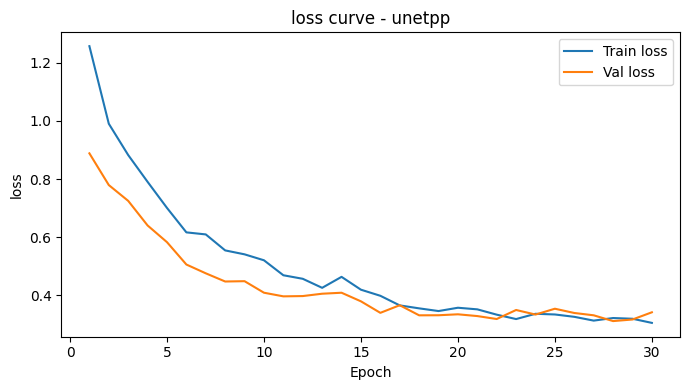

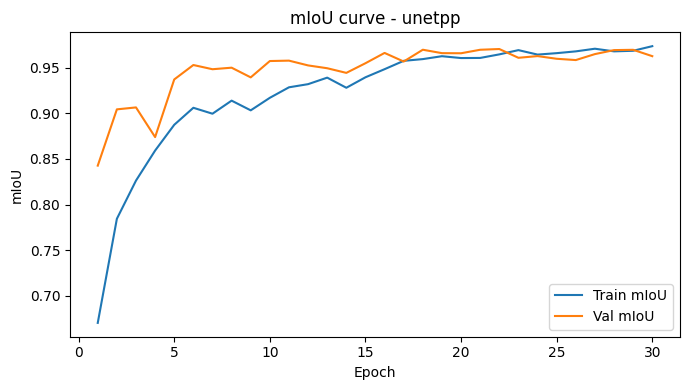

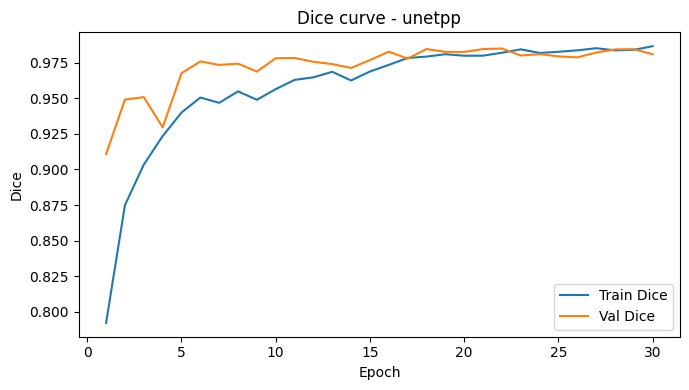

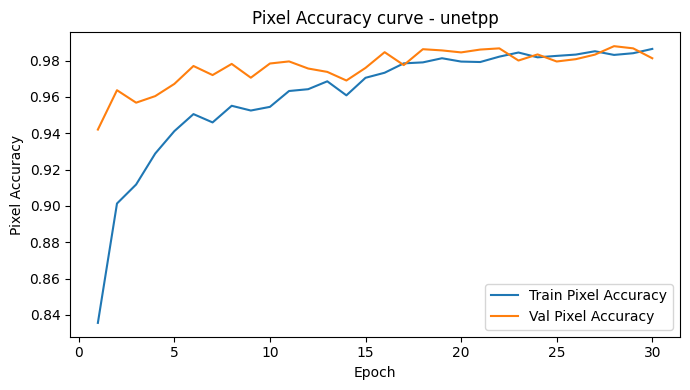

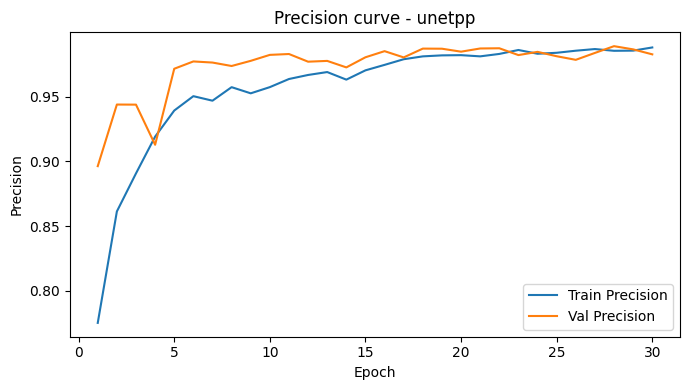

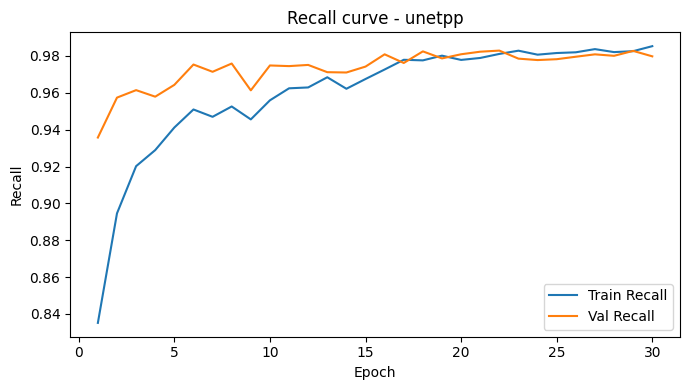

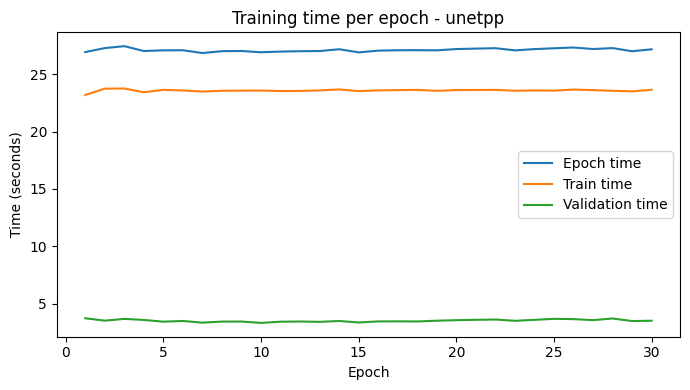

Load best checkpoint: /kaggle/working/dw_direct_compare/best_unetpp.pth
Using single GPU/CPU.
Using class weights:
  water       : 0.898
  vegetation  : 0.671
  agriculture : 0.750
  built_up    : 0.565
  bare        : 2.116
Evaluating on TEST set...


Evaluate:   0%|          | 0/25 [00:00<?, ?it/s]

Measuring inference latency...
Computing ROC/AUC and Precision-Recall curves...


Collect probabilities:   0%|          | 0/25 [00:00<?, ?it/s]

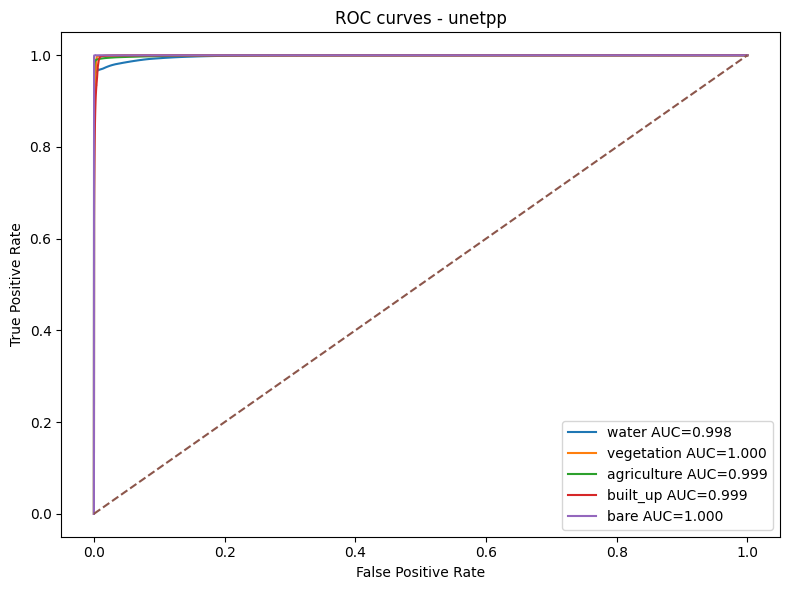

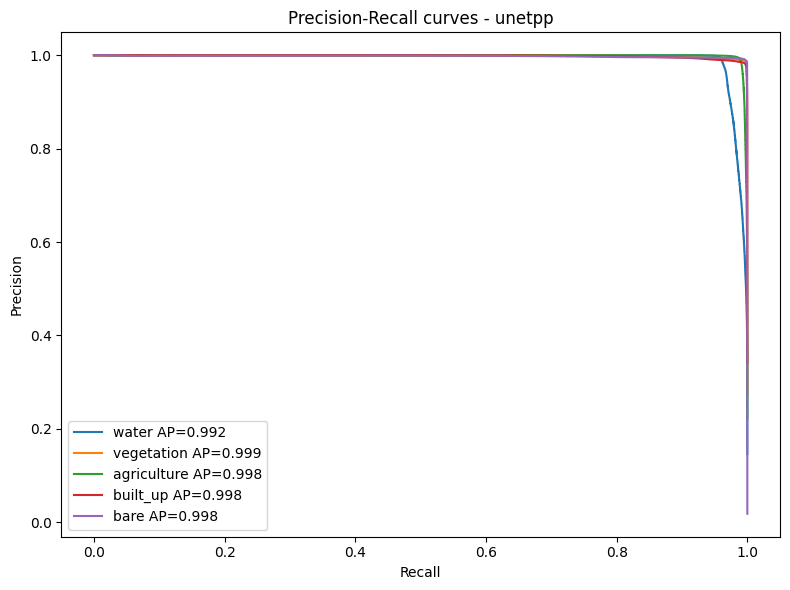

[unetpp] TEST RESULT
  test_loss      : 0.3084
  pixel_accuracy : 0.9884
  mIoU           : 0.9767
  mean_dice      : 0.9882
  mean_precision : 0.9892
  mean_recall    : 0.9874
  test_time_s    : 3.77
  total_train_s  : 813.99
  latency_ms/img : 4.396
  img/s          : 227.481
  ROC AUC macro  : 0.9992
  AP macro       : 0.9971
Saving confusion matrix, per-class metrics, predictions, and report image...


Collect predictions:   0%|          | 0/25 [00:00<?, ?it/s]

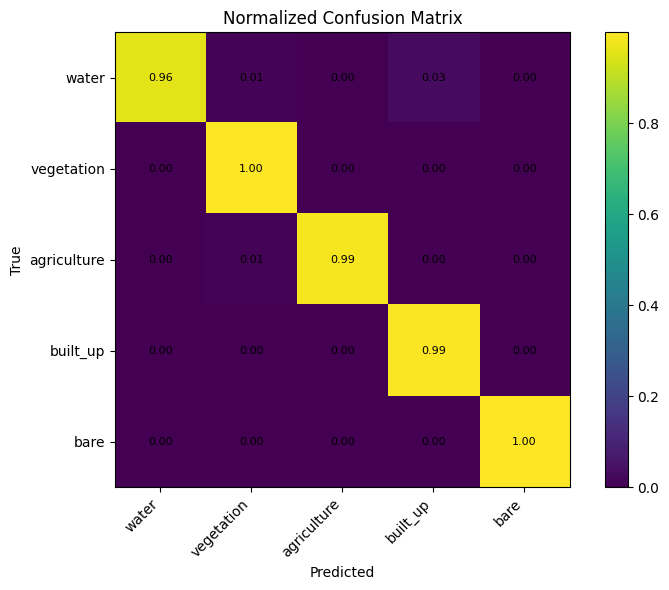

,class_id,class_name,iou,dice,precision,recall,support_pixels
0,0,water,0.954635,0.976791,0.995076,0.959166,514059
1,1,vegetation,0.983773,0.991820,0.986355,0.997346,956044
2,2,agriculture,0.981202,0.990512,0.994888,0.986174,783246
3,3,built_up,0.978394,0.989079,0.983409,0.994815,1199604
4,4,bare,0.985551,0.992723,0.986266,0.999265,63959


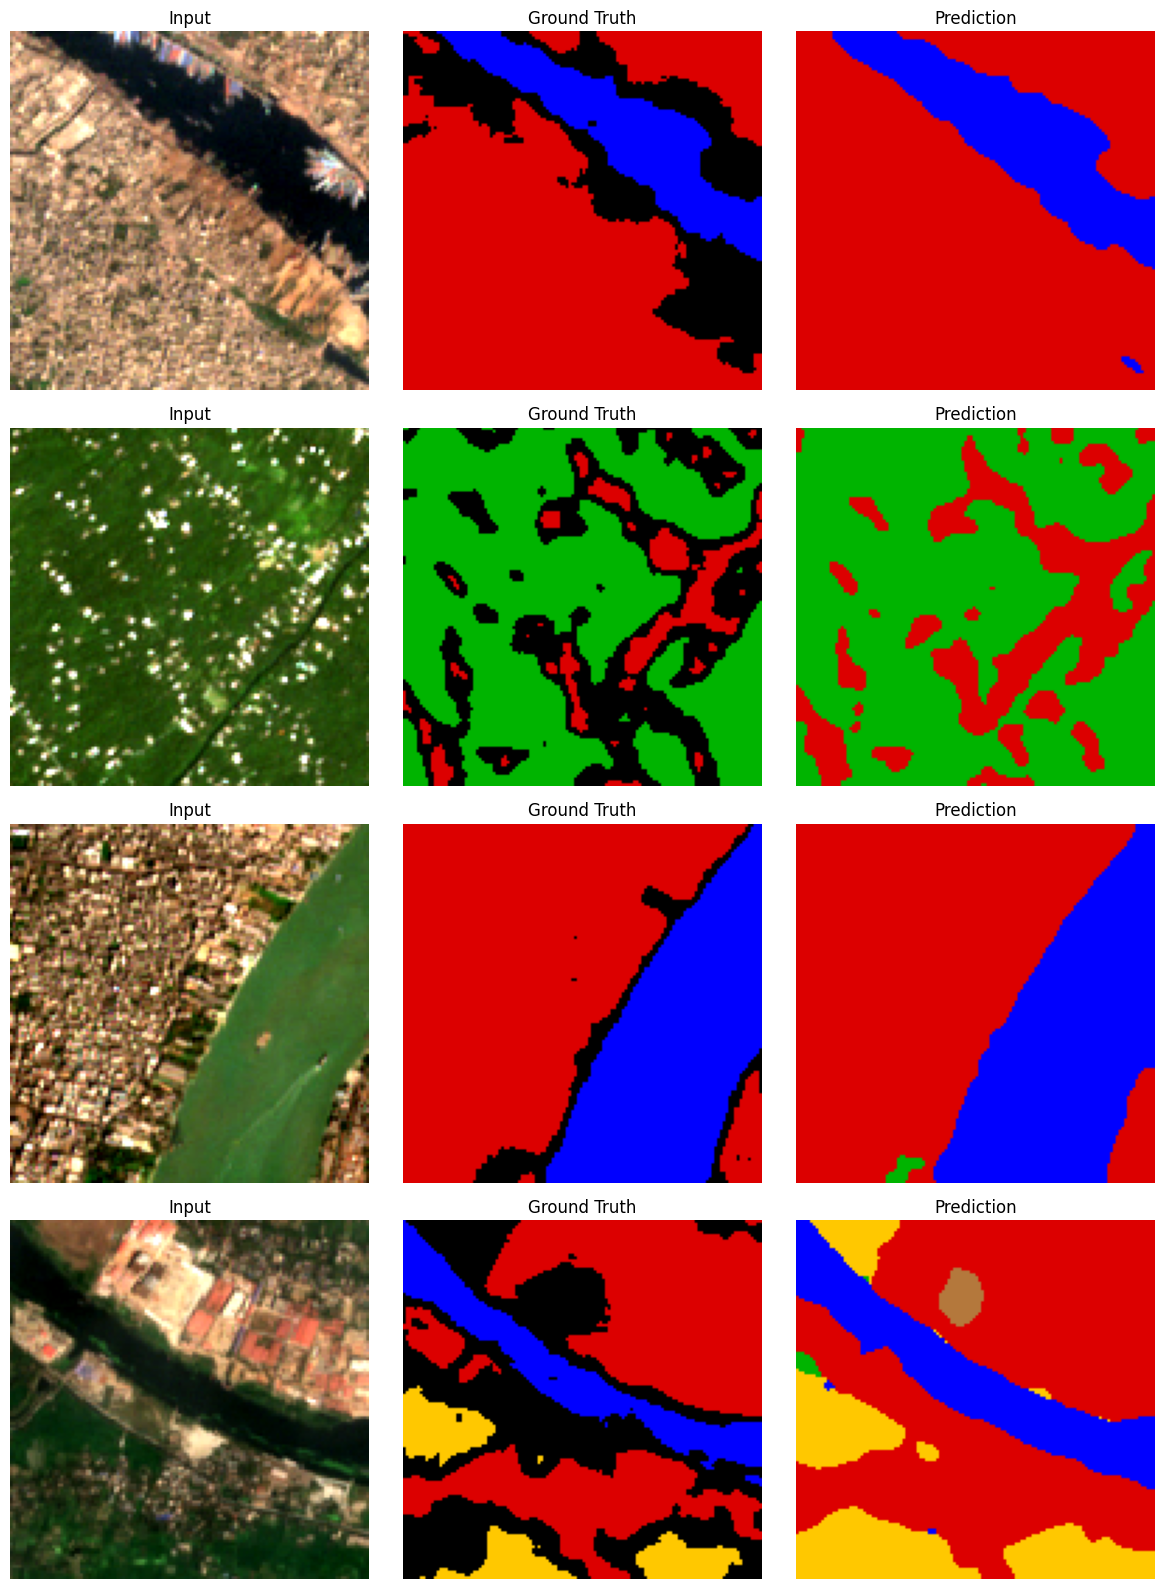

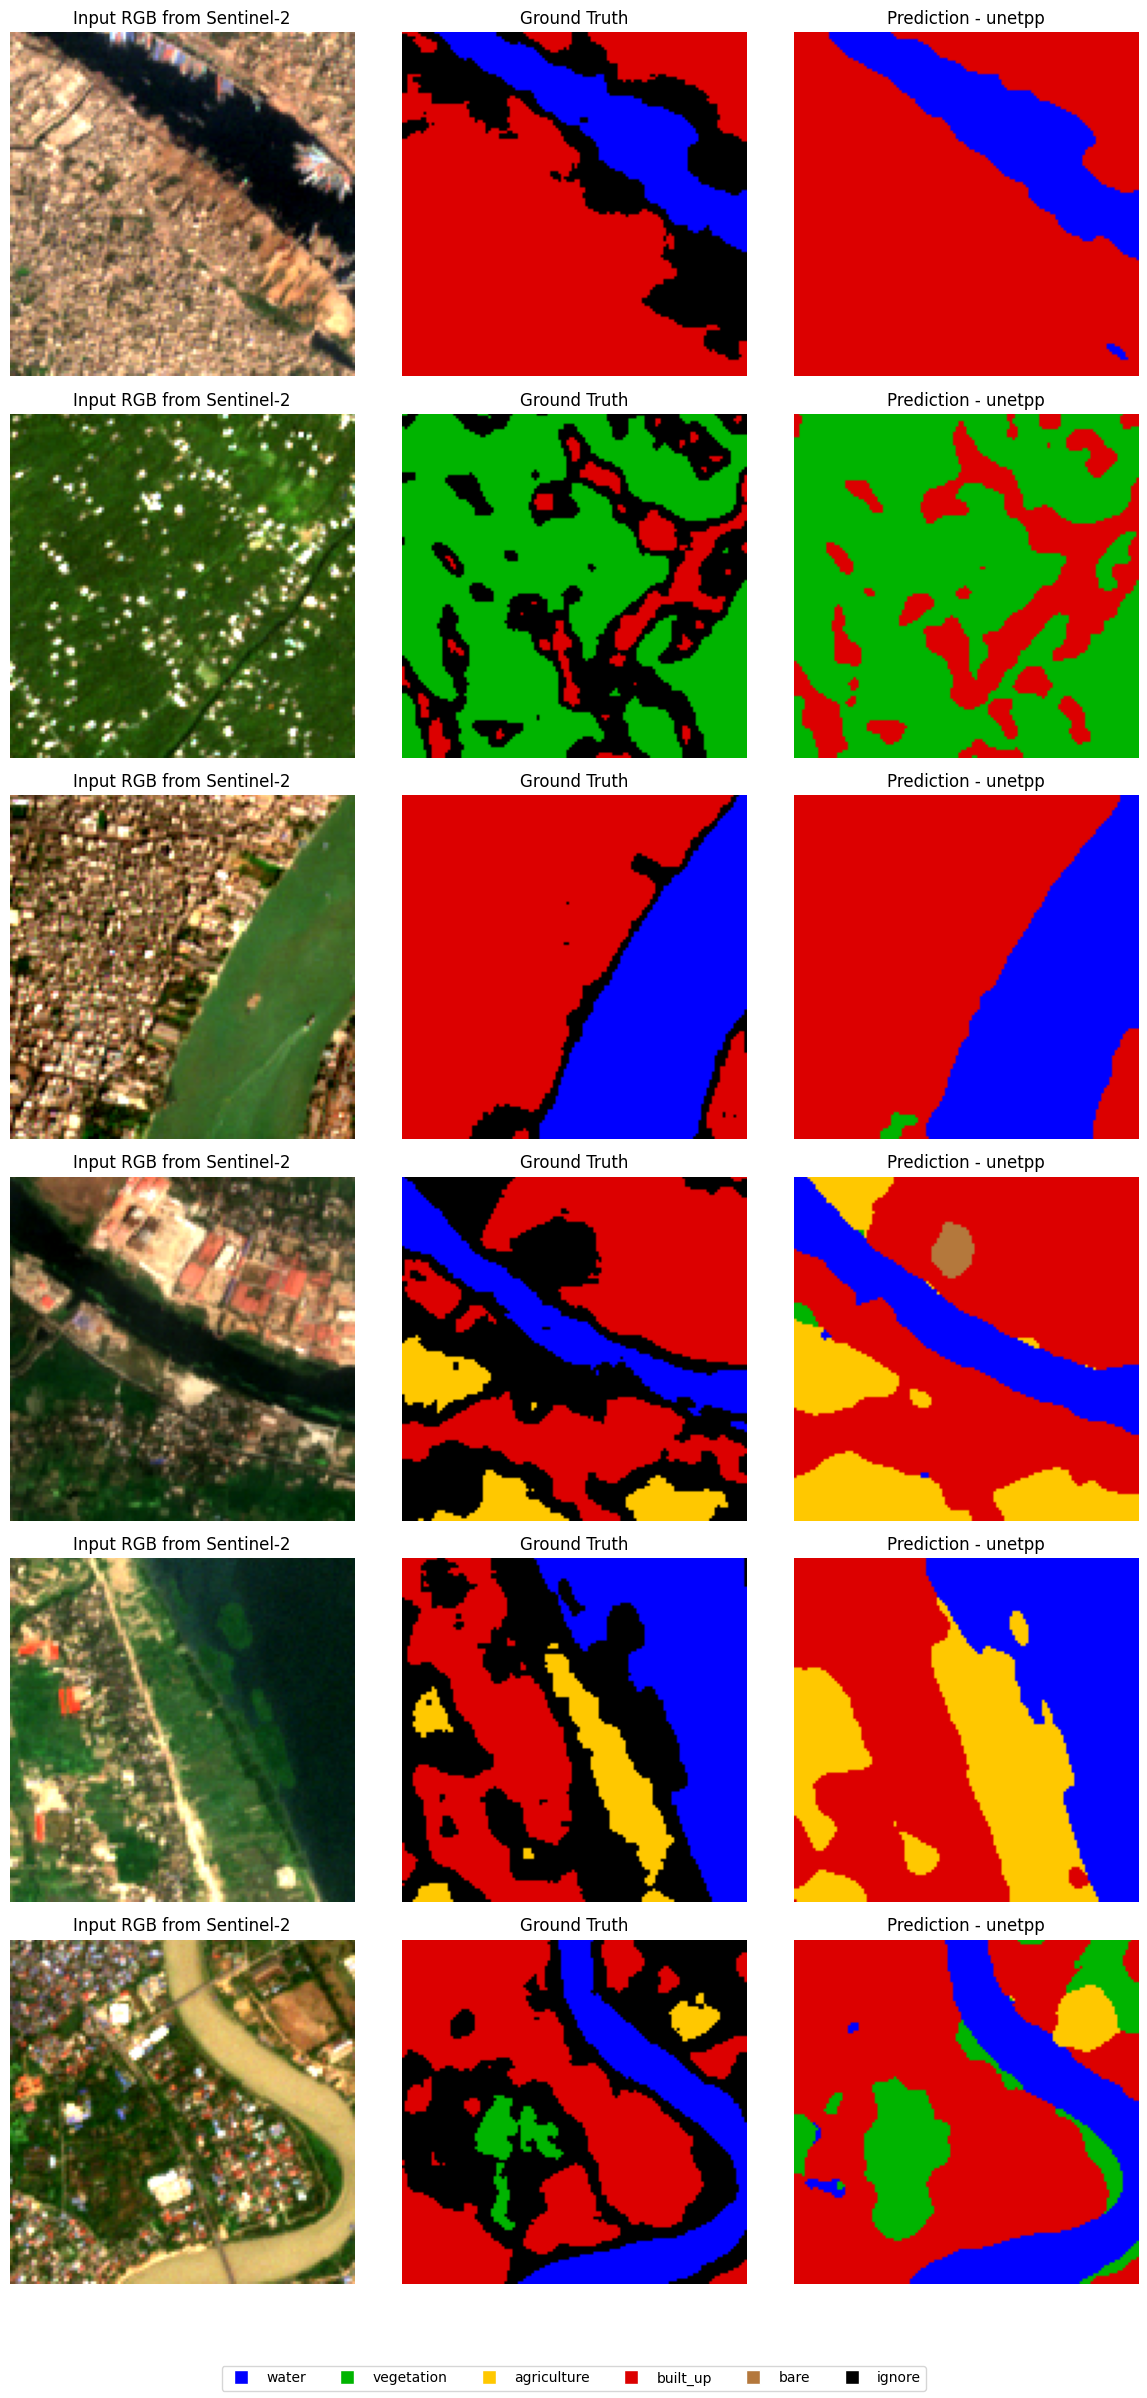

Saved report visualization: /kaggle/working/dw_direct_compare/report_test_predictions_unetpp.png
Saved single model result: /kaggle/working/dw_direct_compare/result_unetpp.csv


,model,total_params,trainable_params,gpu_count,multi_gpu,test_loss,pixel_accuracy,miou,mean_dice,mean_precision,...,latency_ms_per_image,images_per_second,roc_auc_macro,average_precision_macro,best_checkpoint,history_csv,per_class_csv,confusion_matrix_png,prediction_png,report_prediction_png
0,unetpp,9161253,9161253,2,False,0.308434,0.988449,0.976711,0.988185,0.989199,...,4.395965,227.481316,0.999178,0.99713,/kaggle/working/dw_direct_compare/best_unetpp.pth,/kaggle/working/dw_direct_compare/history_unet...,/kaggle/working/dw_direct_compare/per_class_un...,/kaggle/working/dw_direct_compare/cm_unetpp.png,/kaggle/working/dw_direct_compare/predictions_...,/kaggle/working/dw_direct_compare/report_test_...


In [263]:
# ==========================================================
# 6A. Train and evaluate U-Net++
# ==========================================================

OUT_DIR = Path(CONFIG.get("output_dir", "/kaggle/working/dynamicworld_training_outputs"))
OUT_DIR.mkdir(parents=True, exist_ok=True)

if "train_dataset" not in globals():
    if "train_set" in globals():
        train_dataset = train_set
    else:
        raise NameError("Chưa có train_set/train_dataset. Hãy chạy cell chia train/val/test trước.")

if CONFIG.get("use_class_weights", True) and CONFIG.get("class_weights") is None:
    print("Class weights not found. Computing dynamic class weights now...")
    update_class_weights_from_train_dataset(train_dataset, num_classes=num_classes)

unetpp_result = train_one_model_full("unetpp")
display(pd.DataFrame([unetpp_result]))

## 6B. Train và test DeepLabV3+

Training model: deeplabv3plus
Model: deeplabv3plus
Total params: 2,338,821
Trainable params: 2,338,821
Input channels: 8
Classes: 5 -> ['water', 'vegetation', 'agriculture', 'built_up', 'bare']
Removed old checkpoint before clean training: /kaggle/working/dw_direct_compare/best_deeplabv3plus.pth
Using single GPU/CPU.
Using class weights:
  water       : 0.898
  vegetation  : 0.671
  agriculture : 0.750
  built_up    : 0.565
  bare        : 2.116


Train:   0%|          | 0/117 [00:00<?, ?it/s]

Evaluate:   0%|          | 0/25 [00:00<?, ?it/s]

[deeplabv3plus] Epoch 001/30 | loss 1.0377/0.9194 | mIoU 0.6523/0.7624 | Dice 0.7786/0.8582 | Acc 0.8221/0.8385 | lr 1.00e-04 | 20.8s
Saved best checkpoint: /kaggle/working/dw_direct_compare/best_deeplabv3plus.pth | best_val_mIoU=0.7624


Train:   0%|          | 0/117 [00:00<?, ?it/s]

...

Evaluate:   0%|          | 0/25 [00:00<?, ?it/s]

[deeplabv3plus] Epoch 029/30 | loss 0.3055/0.3090 | mIoU 0.9686/0.9710 | Dice 0.9840/0.9852 | Acc 0.9834/0.9870 | lr 5.00e-05 | 18.6s
Saved best checkpoint: /kaggle/working/dw_direct_compare/best_deeplabv3plus.pth | best_val_mIoU=0.9710


Train:   0%|          | 0/117 [00:00<?, ?it/s]

Evaluate:   0%|          | 0/25 [00:00<?, ?it/s]

[deeplabv3plus] Epoch 030/30 | loss 0.2998/0.3059 | mIoU 0.9697/0.9728 | Dice 0.9846/0.9861 | Acc 0.9840/0.9880 | lr 5.00e-05 | 18.5s
Saved best checkpoint: /kaggle/working/dw_direct_compare/best_deeplabv3plus.pth | best_val_mIoU=0.9728
Saved history: /kaggle/working/dw_direct_compare/history_deeplabv3plus.csv


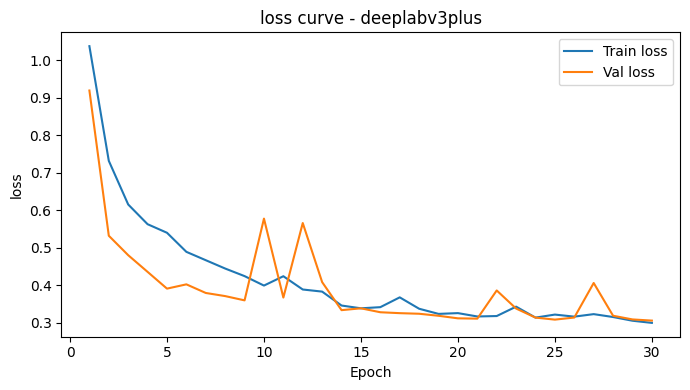

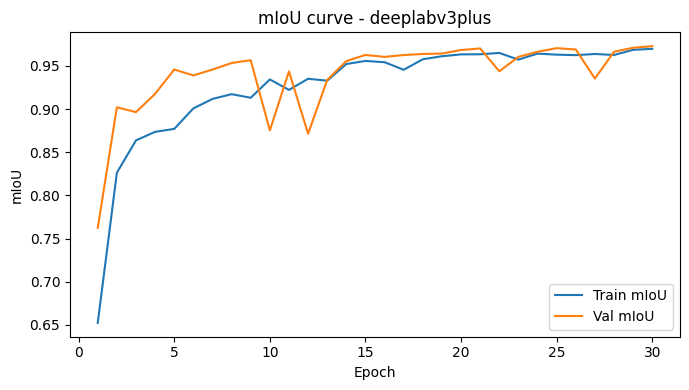

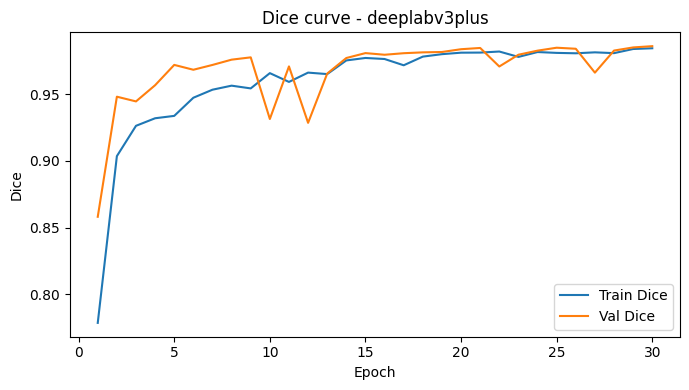

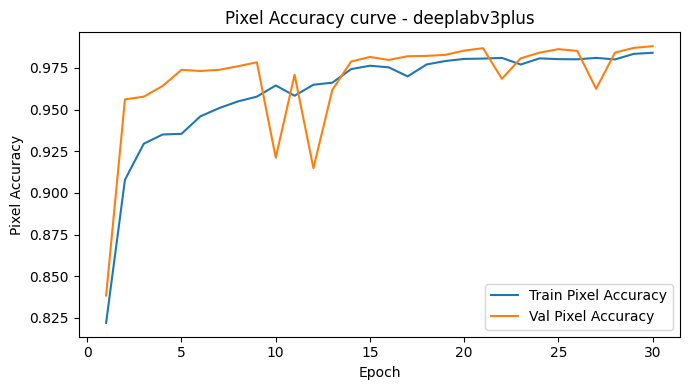

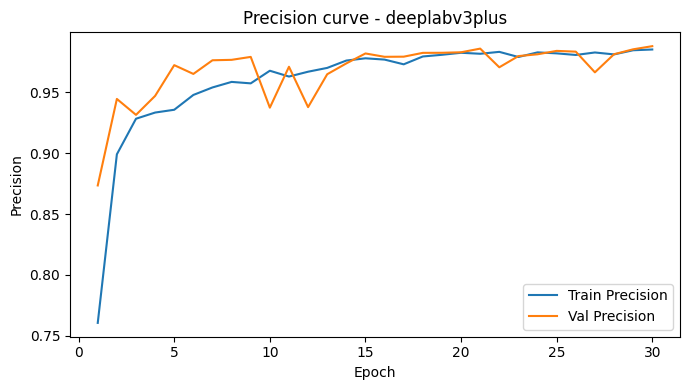

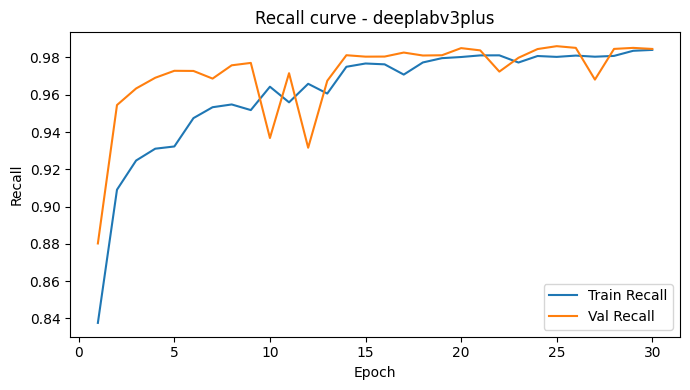

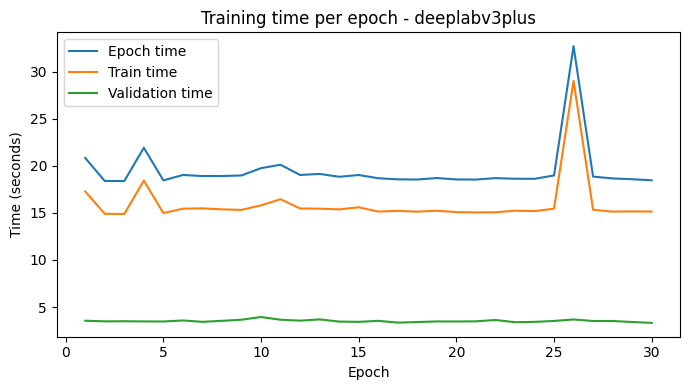

Load best checkpoint: /kaggle/working/dw_direct_compare/best_deeplabv3plus.pth
Using single GPU/CPU.
Using class weights:
  water       : 0.898
  vegetation  : 0.671
  agriculture : 0.750
  built_up    : 0.565
  bare        : 2.116
Evaluating on TEST set...


Evaluate:   0%|          | 0/25 [00:00<?, ?it/s]

Measuring inference latency...
Computing ROC/AUC and Precision-Recall curves...


Collect probabilities:   0%|          | 0/25 [00:00<?, ?it/s]

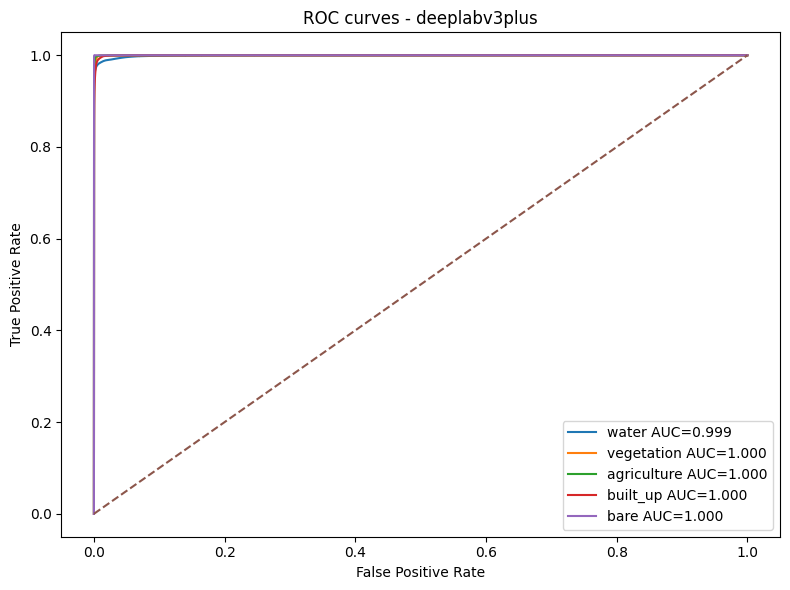

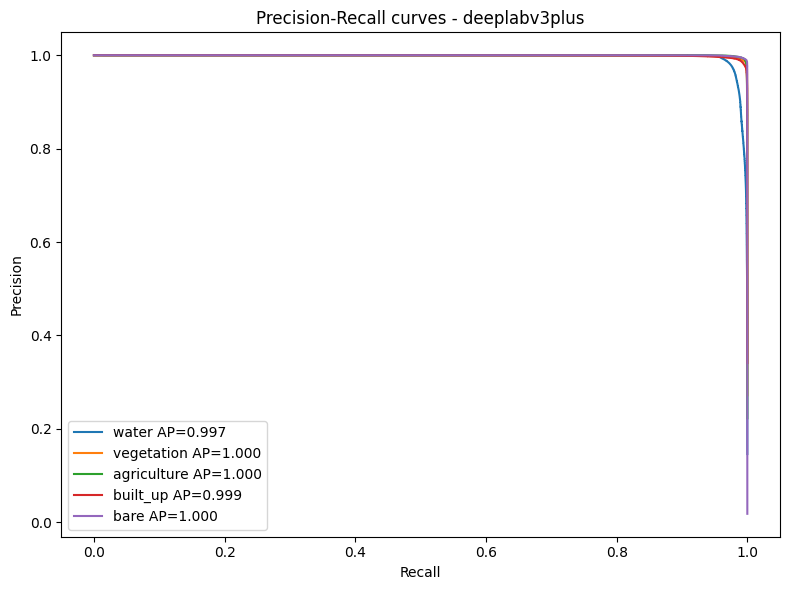

[deeplabv3plus] TEST RESULT
  test_loss      : 0.2886
  pixel_accuracy : 0.9885
  mIoU           : 0.9775
  mean_dice      : 0.9886
  mean_precision : 0.9888
  mean_recall    : 0.9884
  test_time_s    : 3.88
  total_train_s  : 583.59
  latency_ms/img : 2.519
  img/s          : 396.930
  ROC AUC macro  : 0.9997
  AP macro       : 0.9990
Saving confusion matrix, per-class metrics, predictions, and report image...


Collect predictions:   0%|          | 0/25 [00:00<?, ?it/s]

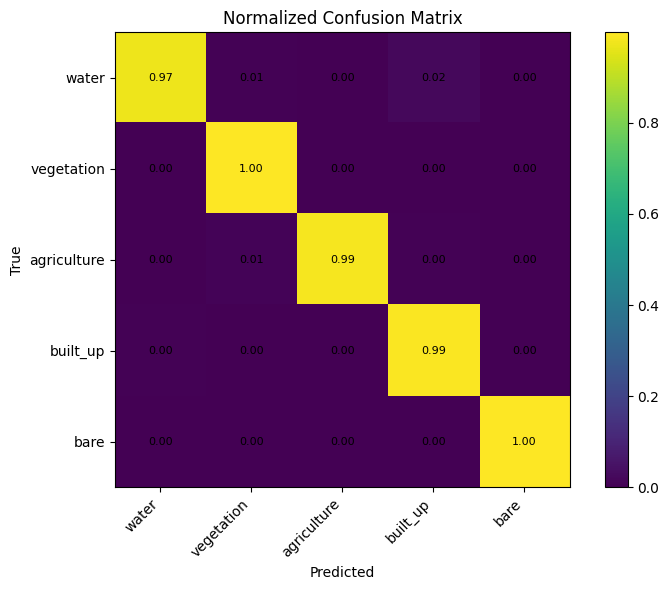

,class_id,class_name,iou,dice,precision,recall,support_pixels
0,0,water,0.956542,0.977789,0.984513,0.971155,514059
1,1,vegetation,0.983114,0.991485,0.987978,0.995017,956044
2,2,agriculture,0.982155,0.990997,0.996289,0.985762,783246
3,3,built_up,0.977671,0.988709,0.985473,0.991967,1199604
4,4,bare,0.988052,0.993990,0.989860,0.998155,63959


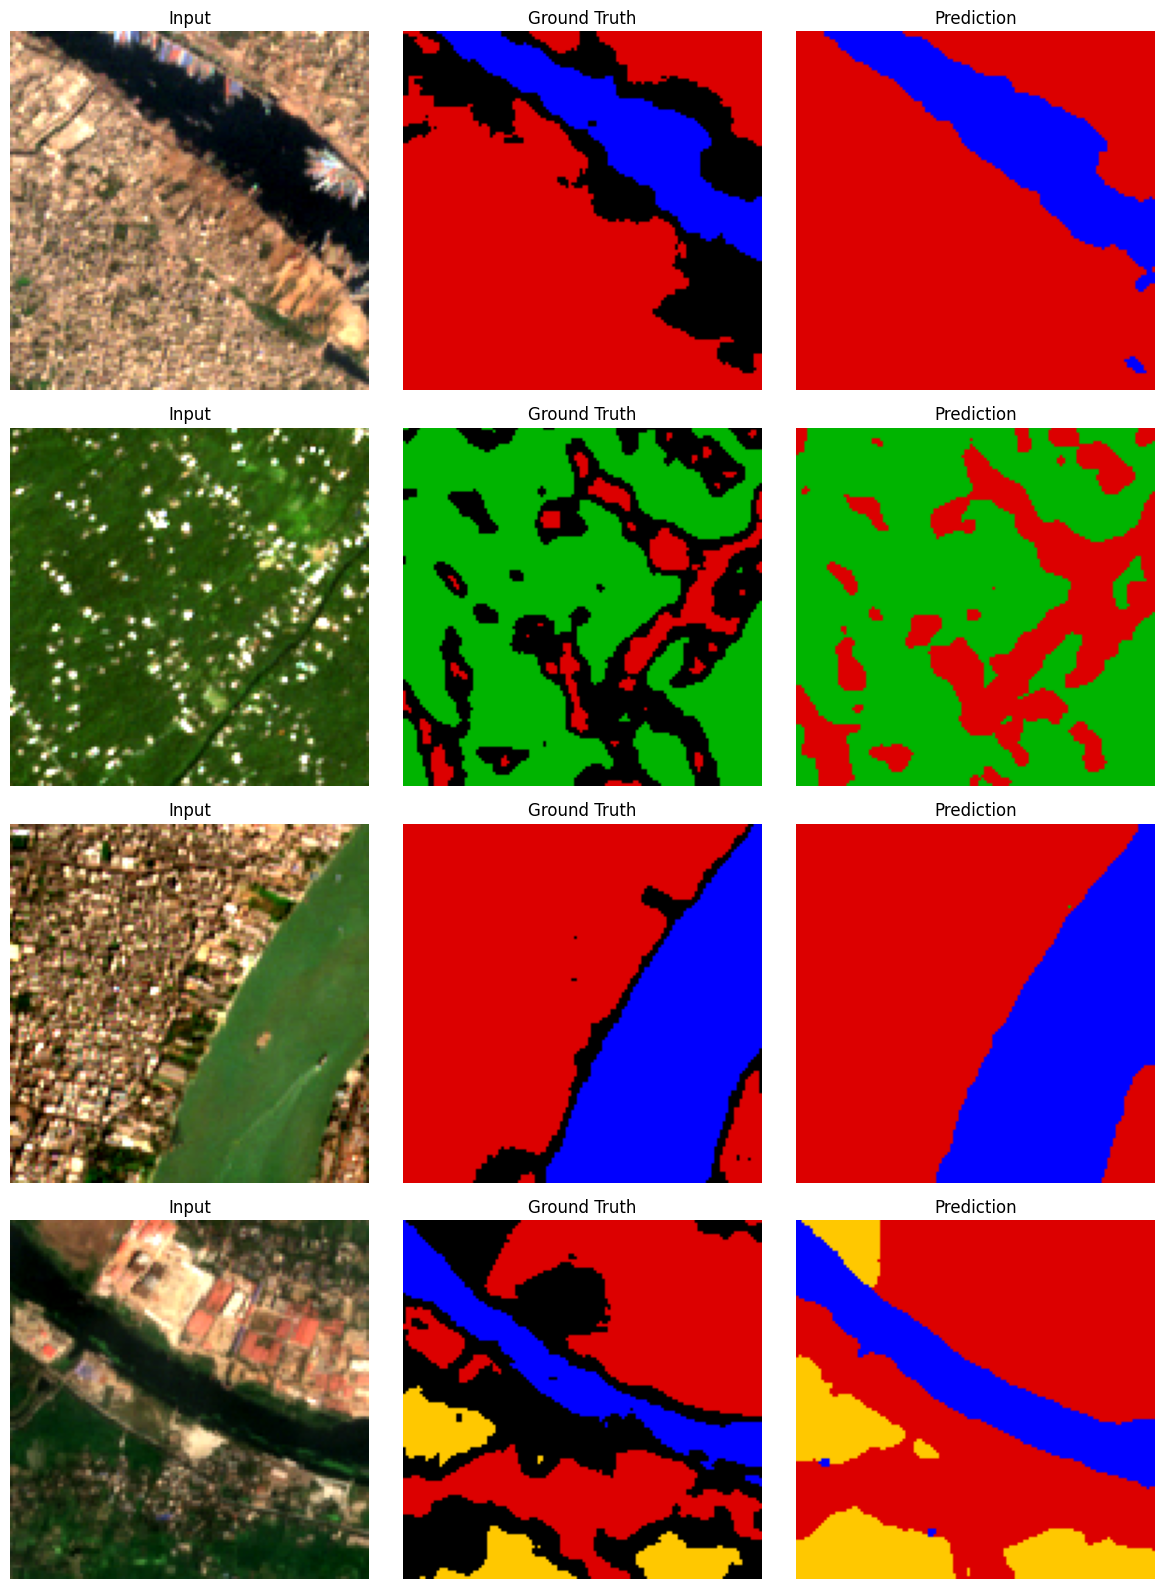

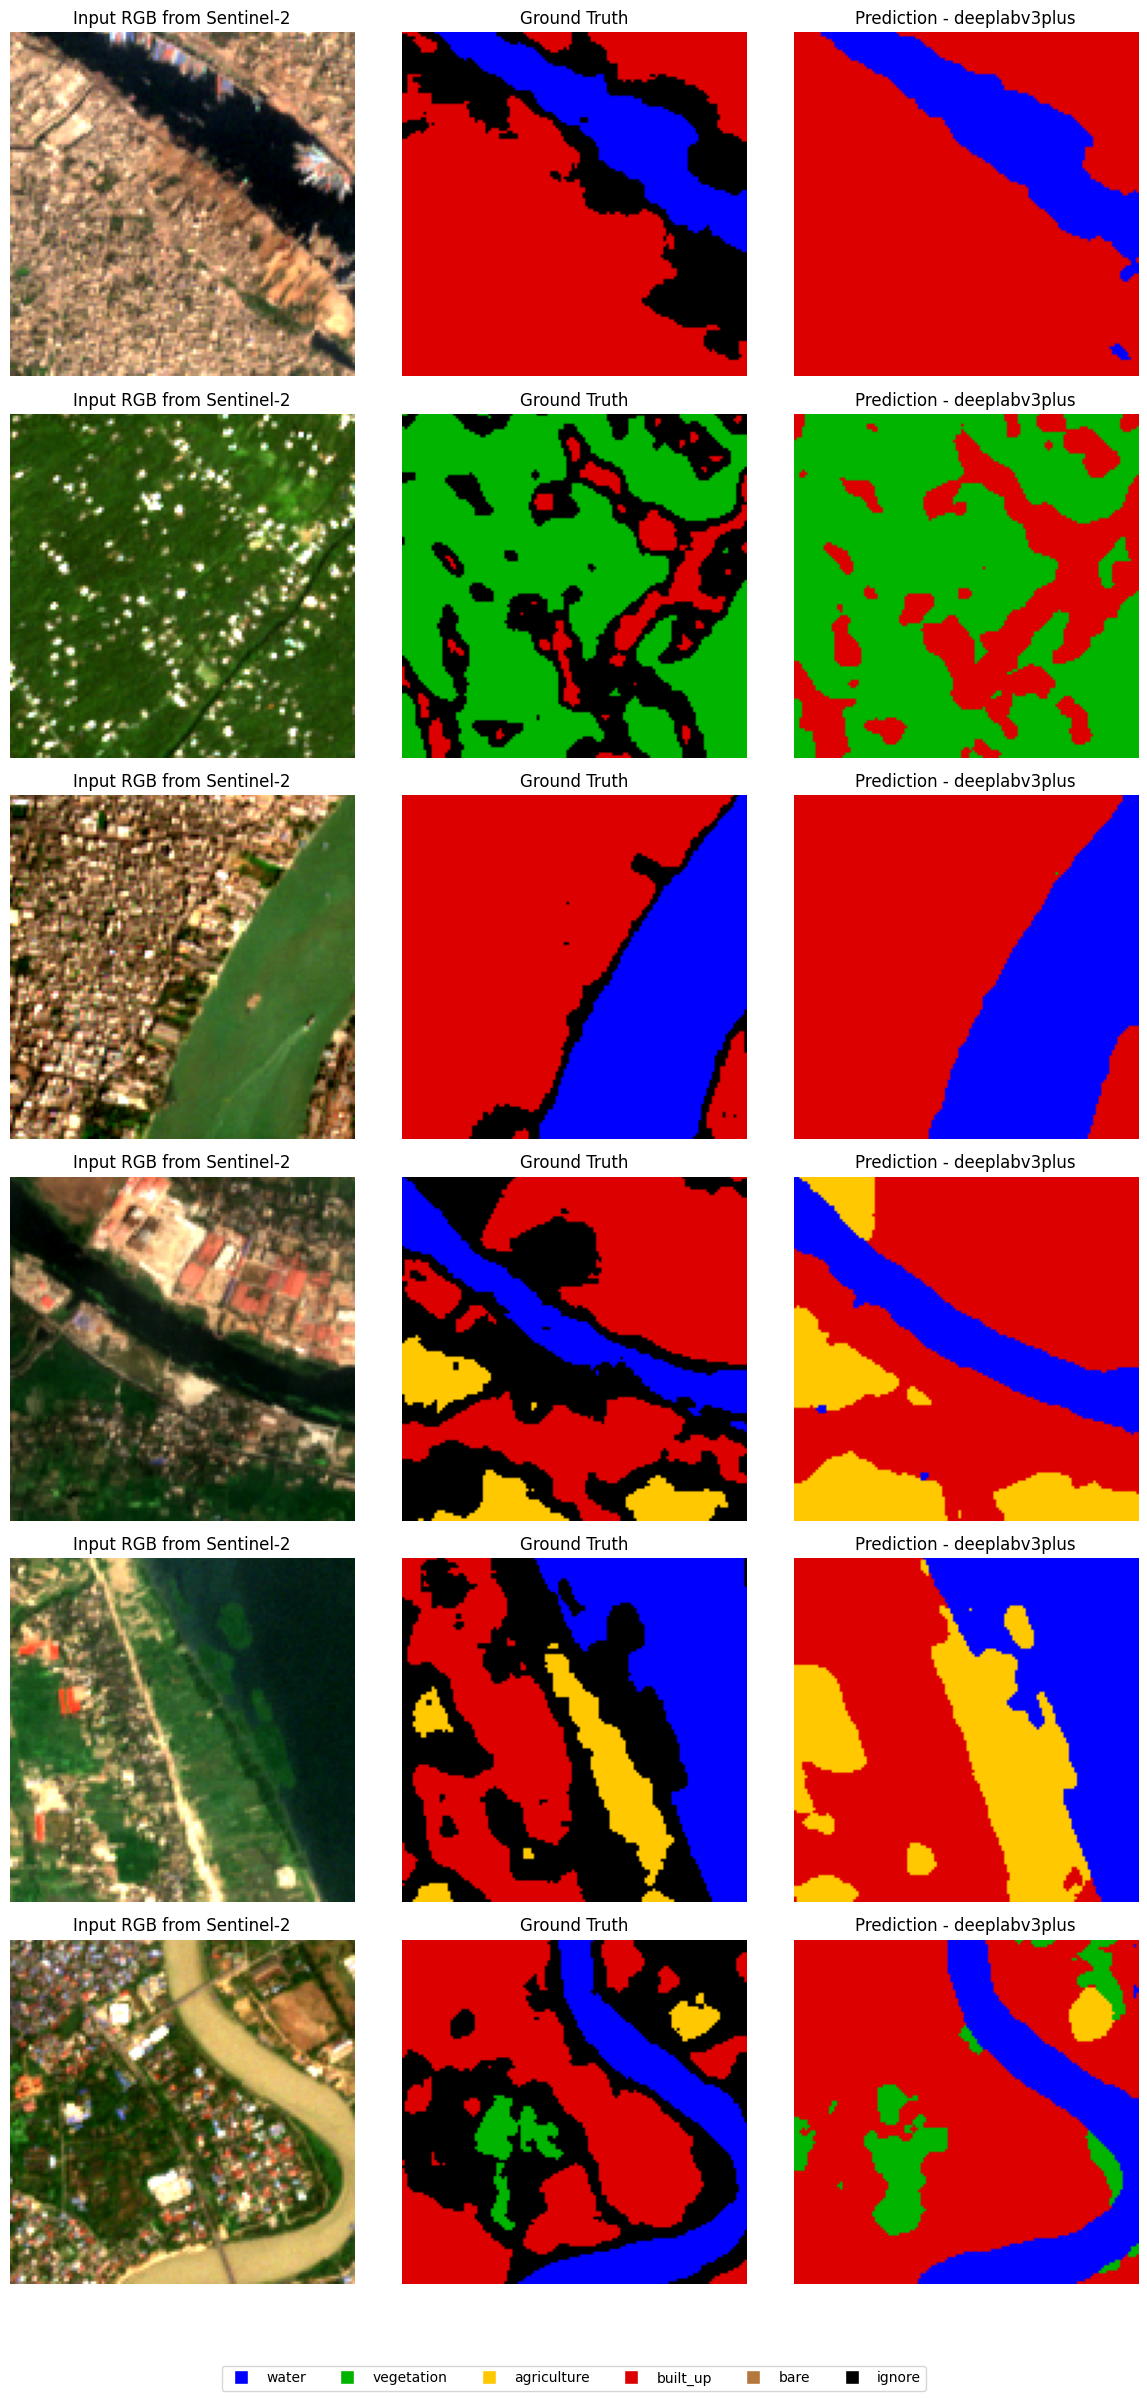

Saved report visualization: /kaggle/working/dw_direct_compare/report_test_predictions_deeplabv3plus.png
Saved single model result: /kaggle/working/dw_direct_compare/result_deeplabv3plus.csv


,model,total_params,trainable_params,gpu_count,multi_gpu,test_loss,pixel_accuracy,miou,mean_dice,mean_precision,...,latency_ms_per_image,images_per_second,roc_auc_macro,average_precision_macro,best_checkpoint,history_csv,per_class_csv,confusion_matrix_png,prediction_png,report_prediction_png
0,deeplabv3plus,2338821,2338821,2,False,0.288638,0.988485,0.977507,0.988594,0.988823,...,2.519334,396.930312,0.999721,0.998989,/kaggle/working/dw_direct_compare/best_deeplab...,/kaggle/working/dw_direct_compare/history_deep...,/kaggle/working/dw_direct_compare/per_class_de...,/kaggle/working/dw_direct_compare/cm_deeplabv3...,/kaggle/working/dw_direct_compare/predictions_...,/kaggle/working/dw_direct_compare/report_test_...


In [264]:
# ==========================================================
# 6B. Train and evaluate DeepLabV3+
# ==========================================================

OUT_DIR = Path(CONFIG.get("output_dir", "/kaggle/working/dynamicworld_training_outputs"))
OUT_DIR.mkdir(parents=True, exist_ok=True)

if "train_dataset" not in globals():
    if "train_set" in globals():
        train_dataset = train_set
    else:
        raise NameError("Chưa có train_set/train_dataset. Hãy chạy cell chia train/val/test trước.")

if CONFIG.get("use_class_weights", True) and CONFIG.get("class_weights") is None:
    print("Class weights not found. Computing dynamic class weights now...")
    update_class_weights_from_train_dataset(train_dataset, num_classes=num_classes)

# Helper đã fix latency/images_per_second, loss và report visualization.
deeplabv3plus_result = train_one_model_full("deeplabv3plus")
display(pd.DataFrame([deeplabv3plus_result]))

## 7. So sánh kết quả U-Net++ và DeepLabV3+

Saved model comparison: /kaggle/working/dw_direct_compare/model_comparison_results.csv


,model,total_params,trainable_params,gpu_count,multi_gpu,test_loss,pixel_accuracy,miou,mean_dice,mean_precision,...,latency_ms_per_image,images_per_second,roc_auc_macro,average_precision_macro,best_checkpoint,history_csv,per_class_csv,confusion_matrix_png,prediction_png,report_prediction_png
0,unetpp,9161253,9161253,2,False,0.308434,0.988449,0.976711,0.988185,0.989199,...,4.395965,227.481316,0.999178,0.997130,/kaggle/working/dw_direct_compare/best_unetpp.pth,/kaggle/working/dw_direct_compare/history_unet...,/kaggle/working/dw_direct_compare/per_class_un...,/kaggle/working/dw_direct_compare/cm_unetpp.png,/kaggle/working/dw_direct_compare/predictions_...,/kaggle/working/dw_direct_compare/report_test_...
1,deeplabv3plus,2338821,2338821,2,False,0.288638,0.988485,0.977507,0.988594,0.988823,...,2.519334,396.930312,0.999721,0.998989,/kaggle/working/dw_direct_compare/best_deeplab...,/kaggle/working/dw_direct_compare/history_deep...,/kaggle/working/dw_direct_compare/per_class_de...,/kaggle/working/dw_direct_compare/cm_deeplabv3...,/kaggle/working/dw_direct_compare/predictions_...,/kaggle/working/dw_direct_compare/report_test_...


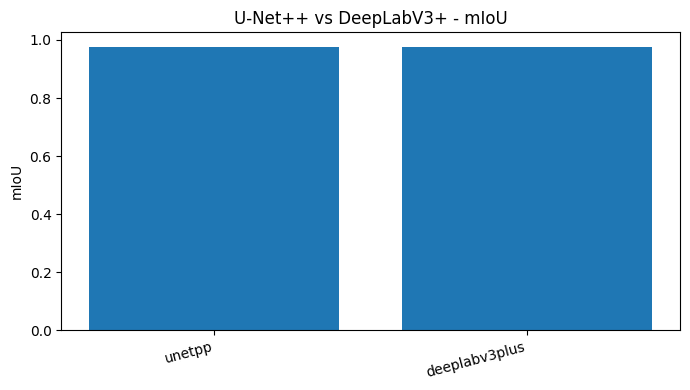

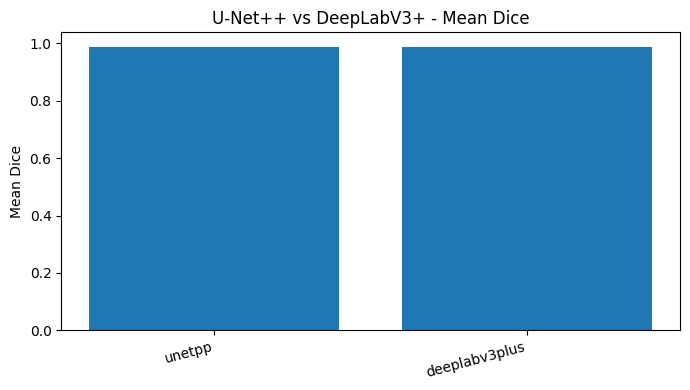

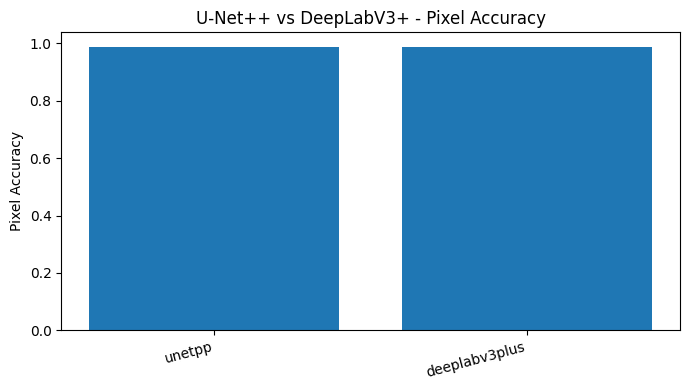

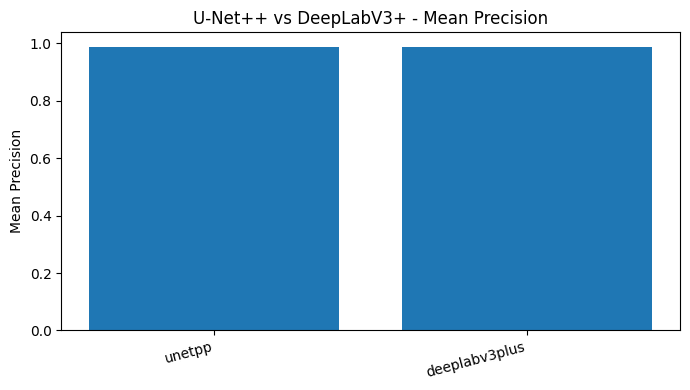

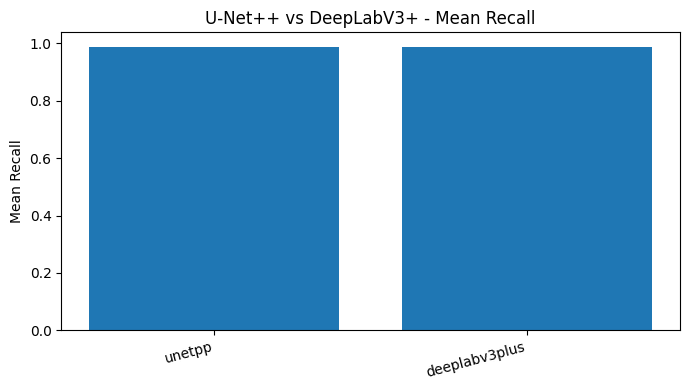

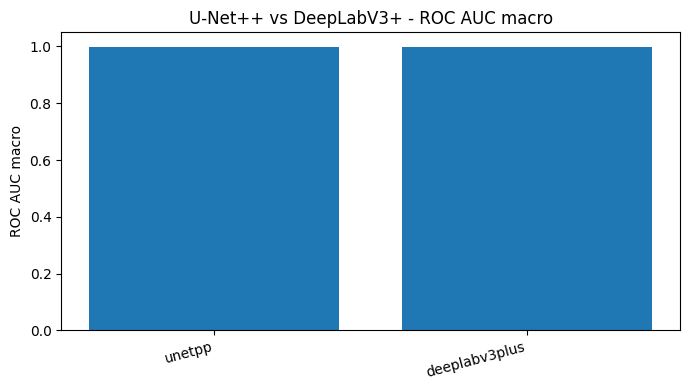

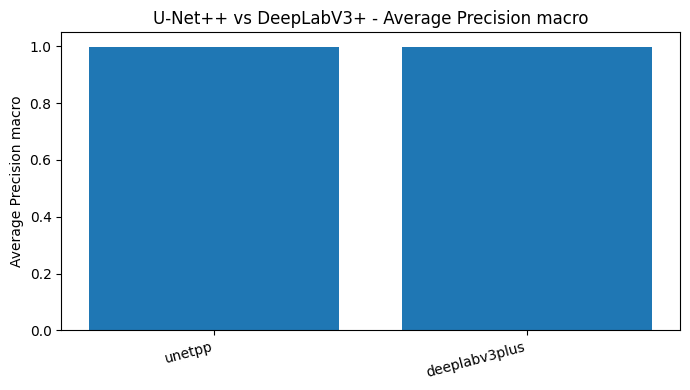

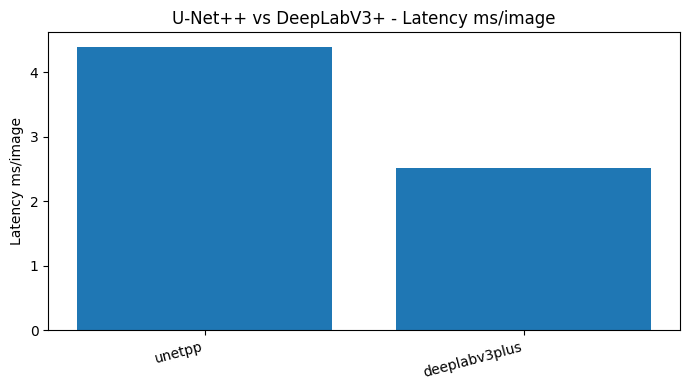

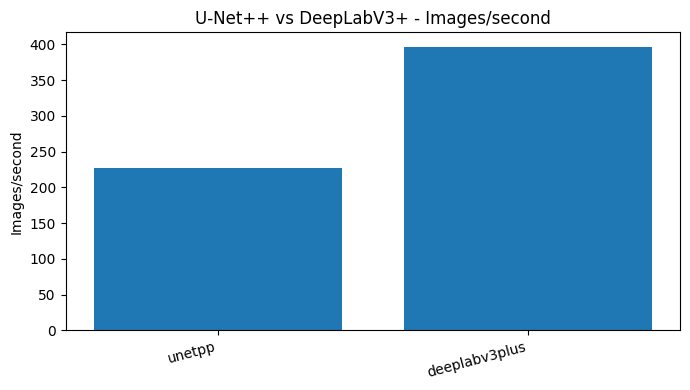

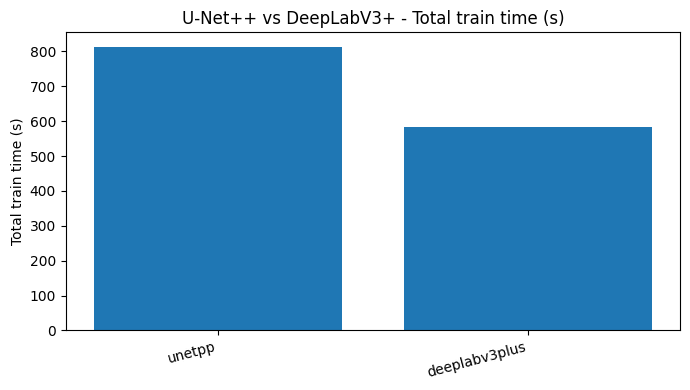

In [265]:
# ==========================================================
# Final comparison: U-Net++ vs DeepLabV3+
# ==========================================================

rows = []

if "unetpp_result" in globals():
    rows.append(unetpp_result)
else:
    p = OUT_DIR / "result_unetpp.csv"
    if p.exists():
        rows.append(pd.read_csv(p).iloc[0].to_dict())

if "deeplabv3plus_result" in globals():
    rows.append(deeplabv3plus_result)
else:
    p = OUT_DIR / "result_deeplabv3plus.csv"
    if p.exists():
        rows.append(pd.read_csv(p).iloc[0].to_dict())

if len(rows) == 0:
    raise RuntimeError("Chưa có kết quả model nào. Hãy chạy cell 6A và/hoặc 6B trước.")

results_df = pd.DataFrame(rows)
results_path = OUT_DIR / "model_comparison_results.csv"
results_df.to_csv(results_path, index=False)

print("Saved model comparison:", results_path)
display(results_df)

comparison_metrics = [
    ("miou", "mIoU"),
    ("mean_dice", "Mean Dice"),
    ("pixel_accuracy", "Pixel Accuracy"),
    ("mean_precision", "Mean Precision"),
    ("mean_recall", "Mean Recall"),
    ("roc_auc_macro", "ROC AUC macro"),
    ("average_precision_macro", "Average Precision macro"),
    ("latency_ms_per_image", "Latency ms/image"),
    ("images_per_second", "Images/second"),
    ("total_train_time_s", "Total train time (s)"),
]

for metric, ylabel in comparison_metrics:
    if metric not in results_df.columns:
        print(f"Skip {metric}: not found in results_df")
        continue

    plt.figure(figsize=(7, 4))
    plt.bar(results_df["model"], results_df[metric])
    plt.title(f"U-Net++ vs DeepLabV3+ - {ylabel}")
    plt.ylabel(ylabel)
    plt.xticks(rotation=15, ha="right")
    plt.tight_layout()
    plt.savefig(OUT_DIR / f"compare_{metric}.png", dpi=180)
    plt.show()